Importar todas las librerías necesarias.

In [ ]:
import pandas as pd
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

Concetar con Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. GENERAR DATASET

In [ ]:
# Ruta de la carpeta
folder_path = "/content/drive/MyDrive/RETO3-SistemaGestiónMicrored/objetivo2/PV_MaximumPowerPredictor/PV_MaximumPowerPredictor"
# Lista todos los archivos en la carpeta que terminan en .csv
files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
files

['Eugene_aSiTandem72-46_cleaned.csv',
 'Eugene_aSiMicro03036_cleaned.csv',
 'Cocoa_aSiMicro03036_cleaned.csv',
 'Cocoa_mSi0166_cleaned.csv',
 'Cocoa_CIGS8-001_cleaned.csv',
 'Cocoa_mSi460A8_cleaned.csv',
 'Cocoa_CIGS39017_cleaned.csv',
 'Cocoa_mSi0188_cleaned.csv',
 'Cocoa_HIT05667_cleaned.csv',
 'Cocoa_aSiTandem72-46_cleaned.csv',
 'Cocoa_xSi12922_cleaned.csv',
 'Cocoa_CdTe75638_cleaned.csv',
 'Eugene_aSiTriple28324_cleaned.csv',
 'Cocoa_aSiTriple28324_cleaned.csv',
 'Eugene_CIGS8-001_cleaned.csv',
 'Golden_aSiTriple28325_cleaned.csv',
 'Golden_aSiTandem90-31_cleaned.csv',
 'Golden_aSiMicro03038_cleaned.csv',
 'Golden_CIGS1-001_cleaned.csv',
 'Golden_CdTe75669_cleaned.csv',
 'Eugene_xSi12922_cleaned.csv',
 'Golden_xSi11246_cleaned.csv',
 'Golden_CIGS39013_cleaned.csv',
 'Eugene_mSi0166_cleaned.csv',
 'Eugene_mSi0188_cleaned.csv',
 'Golden_HIT05662_cleaned.csv',
 'Eugene_CdTe75638_cleaned.csv',
 'Golden_mSi460BB_cleaned.csv',
 'Eugene_CIGS39017_cleaned.csv',
 'Golden_mSi0251_cleaned.cs

Definimos una función para extraer el modelo de la placa del nombre del csv.

In [ ]:
def extraer_modelo(nombre_archivo):
    base     = os.path.basename(nombre_archivo).replace(".csv", "") # Extrae solo el nombre del archivo sin ruta
    panel_id = "_".join(base.split("_")[1:]) # Coge todo después del primer "_"
    match    = re.match(r'^([a-zA-Z]+)', panel_id) # Extrae las primeras letras
    return match.group(1) if match else panel_id # Devuelve el modelo de la placa

In [ ]:
dfs = [] # Lista para almacenar todos los DataFrames

for archivo in files: # Itera sobre archivos CSV encontrados
    nombre = os.path.basename(archivo).replace(".csv","")
    partes = nombre.split("_")
    parque_id = partes[0] # Nombre del parque: Cocoa / Golden / Eugene
    panel_id = "_".join(partes[1:]) # Tipo de panel
    df = pd.read_csv(os.path.join(folder_path, archivo))
    df = df.drop(columns=["Time Stamp (local standard time) yyyy-mm-ddThh:mm:ss"], errors="ignore") # Eliminar timestamp

    # Añadir columnas
    df["parque_id"] = parque_id
    df["panel_id"] = panel_id
    df["modelo_panel"] = extraer_modelo(archivo)

    # Mover columnas al inicio
    cols = ["parque_id","panel_id"] + [c for c in df.columns if c not in ["parque_id","panel_id"]]
    df = df[cols]
    dfs.append(df)

dataset_total = pd.concat(dfs, ignore_index=True)
print(dataset_total.shape)
dataset_total.head()

(1025599, 13)


,parque_id,panel_id,POA irradiance CMP22 pyranometer (W/m2),PV module back surface temperature (degC),Pmp (W),Dry bulb temperature (degC),Relative humidity (%RH),Atmospheric pressure (mb),Precipitation (mm) accumulated daily total,Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Diffuse horizontal irradiance (W/m2),modelo_panel
0,Eugene,aSiTandem72-46_cleaned,22.7,4.9,0.8391,3.9,86.0,989.1,18.8,0.0,28.0,28.3,aSiTandem
1,Eugene,aSiTandem72-46_cleaned,31.2,5.0,1.1929,3.9,85.6,989.1,18.8,0.1,37.4,37.9,aSiTandem
2,Eugene,aSiTandem72-46_cleaned,33.8,5.2,1.2934,3.9,85.9,989.3,18.8,0.1,41.1,41.8,aSiTandem
3,Eugene,aSiTandem72-46_cleaned,29.6,5.1,1.1089,3.9,85.9,989.2,18.8,0.1,35.7,36.2,aSiTandem
4,Eugene,aSiTandem72-46_cleaned,32.7,5.2,1.2329,3.9,85.4,989.2,18.9,0.1,40.2,40.8,aSiTandem


# 2. EXPLORAR LOS DATOS

In [ ]:
dataset_total["parque_id"].value_counts() # Comprobar num de parques y paneles

,count
parque_id,
Eugene,473348
Cocoa,421664
Golden,130587


Los parques Eugene (473k obs.) y Cocoa (422k obs.) presentan datasets robustos, mientras Golden (131k obs.) tiene significativamente menos datos.

In [ ]:
dataset_total["panel_id"].nunique()

22

Hay 22 tipo de paneles diferentes.

In [ ]:
dataset_total["modelo_panel"].nunique()

8

Hay 8 modelos de paneles diferentes.

In [ ]:
pd.crosstab(dataset_total["parque_id"], dataset_total["panel_id"])

panel_id,CIGS1-001_cleaned,CIGS39013_cleaned,CIGS39017_cleaned,CIGS8-001_cleaned,CdTe75638_cleaned,CdTe75669_cleaned,HIT05662_cleaned,HIT05667_cleaned,aSiMicro03036_cleaned,aSiMicro03038_cleaned,...,aSiTriple28324_cleaned,aSiTriple28325_cleaned,mSi0166_cleaned,mSi0188_cleaned,mSi0247_cleaned,mSi0251_cleaned,mSi460A8_cleaned,mSi460BB_cleaned,xSi11246_cleaned,xSi12922_cleaned
parque_id,,,,,,,,,,,,,,,,,,,,,
Cocoa,0,0,34775,38939,39080,0,0,38377,39037,0,...,38485,0,36765,39102,0,0,38929,0,0,38989
Eugene,0,0,42674,43146,42248,0,0,43271,43343,0,...,42705,0,43268,43127,0,0,43115,0,0,43185
Golden,12011,11437,0,0,0,11953,11876,0,0,12148,...,0,11445,0,0,11912,11887,0,11919,11929,0


Vemos que las placas de los parques Cocoa y Eugene coinciden y que los del parque Golden son diferentes.

In [ ]:
pd.crosstab(dataset_total["parque_id"], dataset_total["modelo_panel"])

modelo_panel,CIGS,CdTe,HIT,aSiMicro,aSiTandem,aSiTriple,mSi,xSi
parque_id,,,,,,,,
Cocoa,73714,39080,38377,39037,39186,38485,114796,38989
Eugene,85820,42248,43271,43343,43266,42705,129510,43185
Golden,23448,11953,11876,12148,12070,11445,35718,11929


Los tres parques tienen los mismos modelos de placas.

In [ ]:
dataset_total.isna().sum()

,0
parque_id,0
panel_id,0
POA irradiance CMP22 pyranometer (W/m2),0
PV module back surface temperature (degC),0
Pmp (W),0
Dry bulb temperature (degC),0
Relative humidity (%RH),0
Atmospheric pressure (mb),0
Precipitation (mm) accumulated daily total,0
Direct normal irradiance (W/m2),0


No hay valores faltantes en el dataset.

### Análisis de outliers

In [ ]:
dataset_total.describe()

,POA irradiance CMP22 pyranometer (W/m2),PV module back surface temperature (degC),Pmp (W),Dry bulb temperature (degC),Relative humidity (%RH),Atmospheric pressure (mb),Precipitation (mm) accumulated daily total,Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Diffuse horizontal irradiance (W/m2)
count,1.025599e+06,1.025599e+06,1.025599e+06,1.025599e+06,1.025599e+06,1.025599e+06,1.025599e+06,1.025599e+06,1.025599e+06,1.025599e+06
mean,4.217213e+02,2.965387e+01,3.328415e+01,-1.318447e+02,-4.391351e+02,4.427708e+02,-6.150422e+02,-1.274002e+02,-1.366357e+02,-3.635282e+02
std,3.468253e+02,1.327209e+01,3.753182e+01,1.221602e+03,2.187702e+03,2.390059e+03,2.403906e+03,2.290217e+03,2.275456e+03,2.207168e+03
min,1.990000e+01,-1.890000e+01,1.395000e-01,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03,-9.999000e+03
25%,1.148000e+02,1.950000e+01,6.775000e+00,1.250000e+01,4.600000e+01,9.965000e+02,0.000000e+00,6.000000e-01,1.063000e+02,6.260000e+01
50%,2.988000e+02,2.940000e+01,2.027940e+01,2.060000e+01,6.160000e+01,1.005000e+03,0.000000e+00,1.782000e+02,2.651000e+02,1.024000e+02
75%,7.380000e+02,3.970000e+01,4.641705e+01,2.590000e+01,7.580000e+01,1.014700e+03,0.000000e+00,7.908000e+02,5.871000e+02,1.812000e+02
max,1.443500e+03,7.320000e+01,2.847189e+02,4.100000e+01,1.000000e+02,1.030700e+03,5.920000e+01,1.069000e+03,1.406600e+03,9.690000e+02


Vemos que en las variables "Dry bulb temperature (degC)", "Relative humidity (%RH)", "Atmospheric pressure (mb)", "Precipitation (mm) accumulated daily total", "Direct normal irradiance (W/m2)", "Global horizontal irradiance (W/m2)" y "Diffuse horizontal irradiance (W/m2)" el mínimo es -999.

Vamos a graficar sus distribuciones.

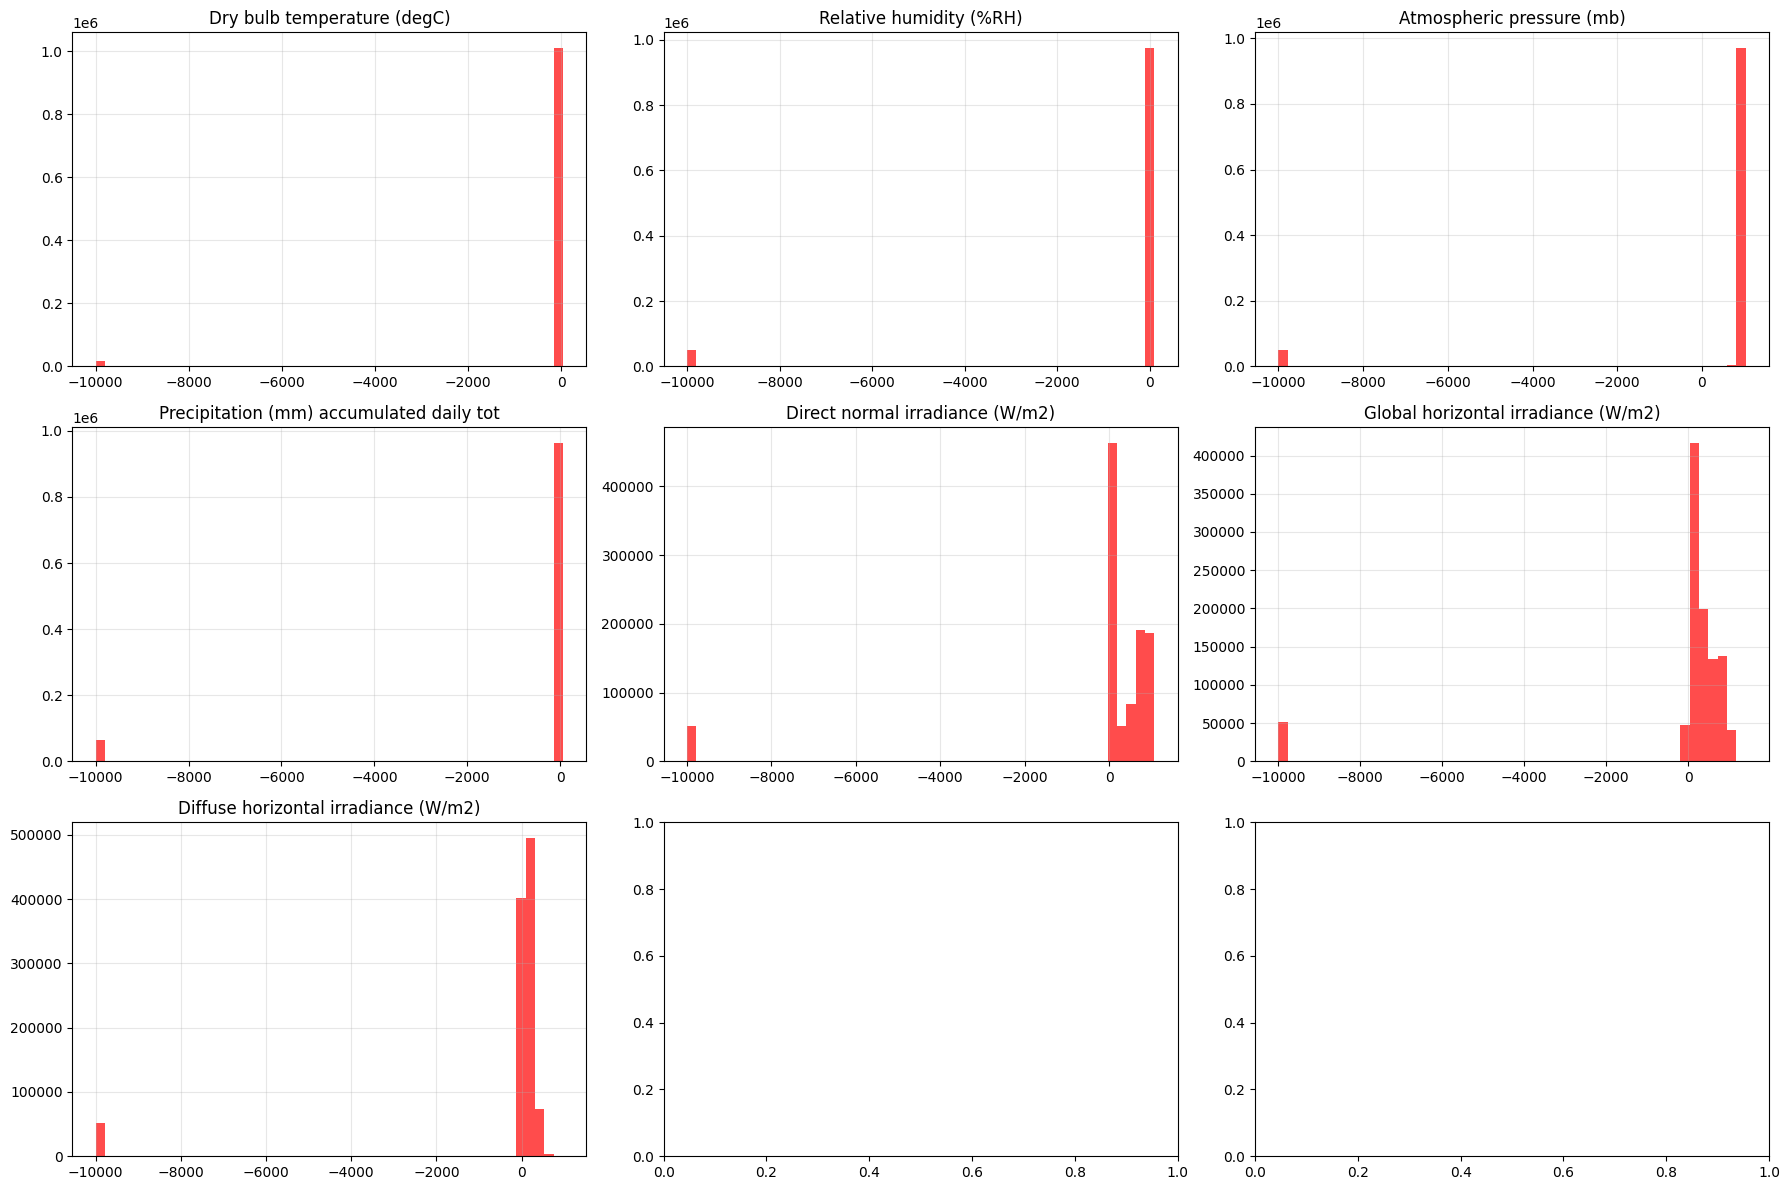

In [ ]:
vars = [
    "Dry bulb temperature (degC)",
    "Relative humidity (%RH)",
    "Atmospheric pressure (mb)",
    "Precipitation (mm) accumulated daily total",
    "Direct normal irradiance (W/m2)",
    "Global horizontal irradiance (W/m2)",
    "Diffuse horizontal irradiance (W/m2)"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, var in enumerate(vars):
    ax = axes[idx]
    dataset_total[var].hist(bins=50, ax=ax, alpha=0.7, color='red')
    ax.set_title(f'{var[:40]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Los valores -999 representan outliers que corresponden a datos faltantes (missing values) codificados numéricamente. Estos valores físicos imposibles confirman la eliminación previa al análisis.

In [ ]:
dataset_total = dataset_total.replace(-9999, np.nan)
dataset_total = dataset_total.dropna()

In [ ]:
dataset_total.describe()

,POA irradiance CMP22 pyranometer (W/m2),PV module back surface temperature (degC),Pmp (W),Dry bulb temperature (degC),Relative humidity (%RH),Atmospheric pressure (mb),Precipitation (mm) accumulated daily total,Direct normal irradiance (W/m2),Global horizontal irradiance (W/m2),Diffuse horizontal irradiance (W/m2)
count,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000,962440.000000
mean,419.073269,29.467554,33.109488,19.317690,61.454120,989.396137,0.769051,390.631045,380.965122,141.156003
std,346.843670,13.214163,37.509871,8.305093,19.398323,56.567985,3.476576,387.059795,298.460348,102.224197
min,19.900000,-18.900000,0.139500,-16.100000,4.600000,797.900000,0.000000,-4.700000,-1.700000,-1.700000
25%,112.900000,19.300000,6.666200,12.900000,48.800000,997.600000,0.000000,0.900000,125.400000,67.900000
50%,295.100000,29.300000,20.023850,20.700000,62.900000,1006.300000,0.000000,299.600000,288.000000,107.800000
75%,733.200000,39.500000,46.096500,25.900000,76.600000,1015.000000,0.000000,802.400000,612.300000,187.200000
max,1443.500000,73.200000,284.718900,39.100000,100.000000,1030.700000,59.200000,1069.000000,1406.600000,969.000000


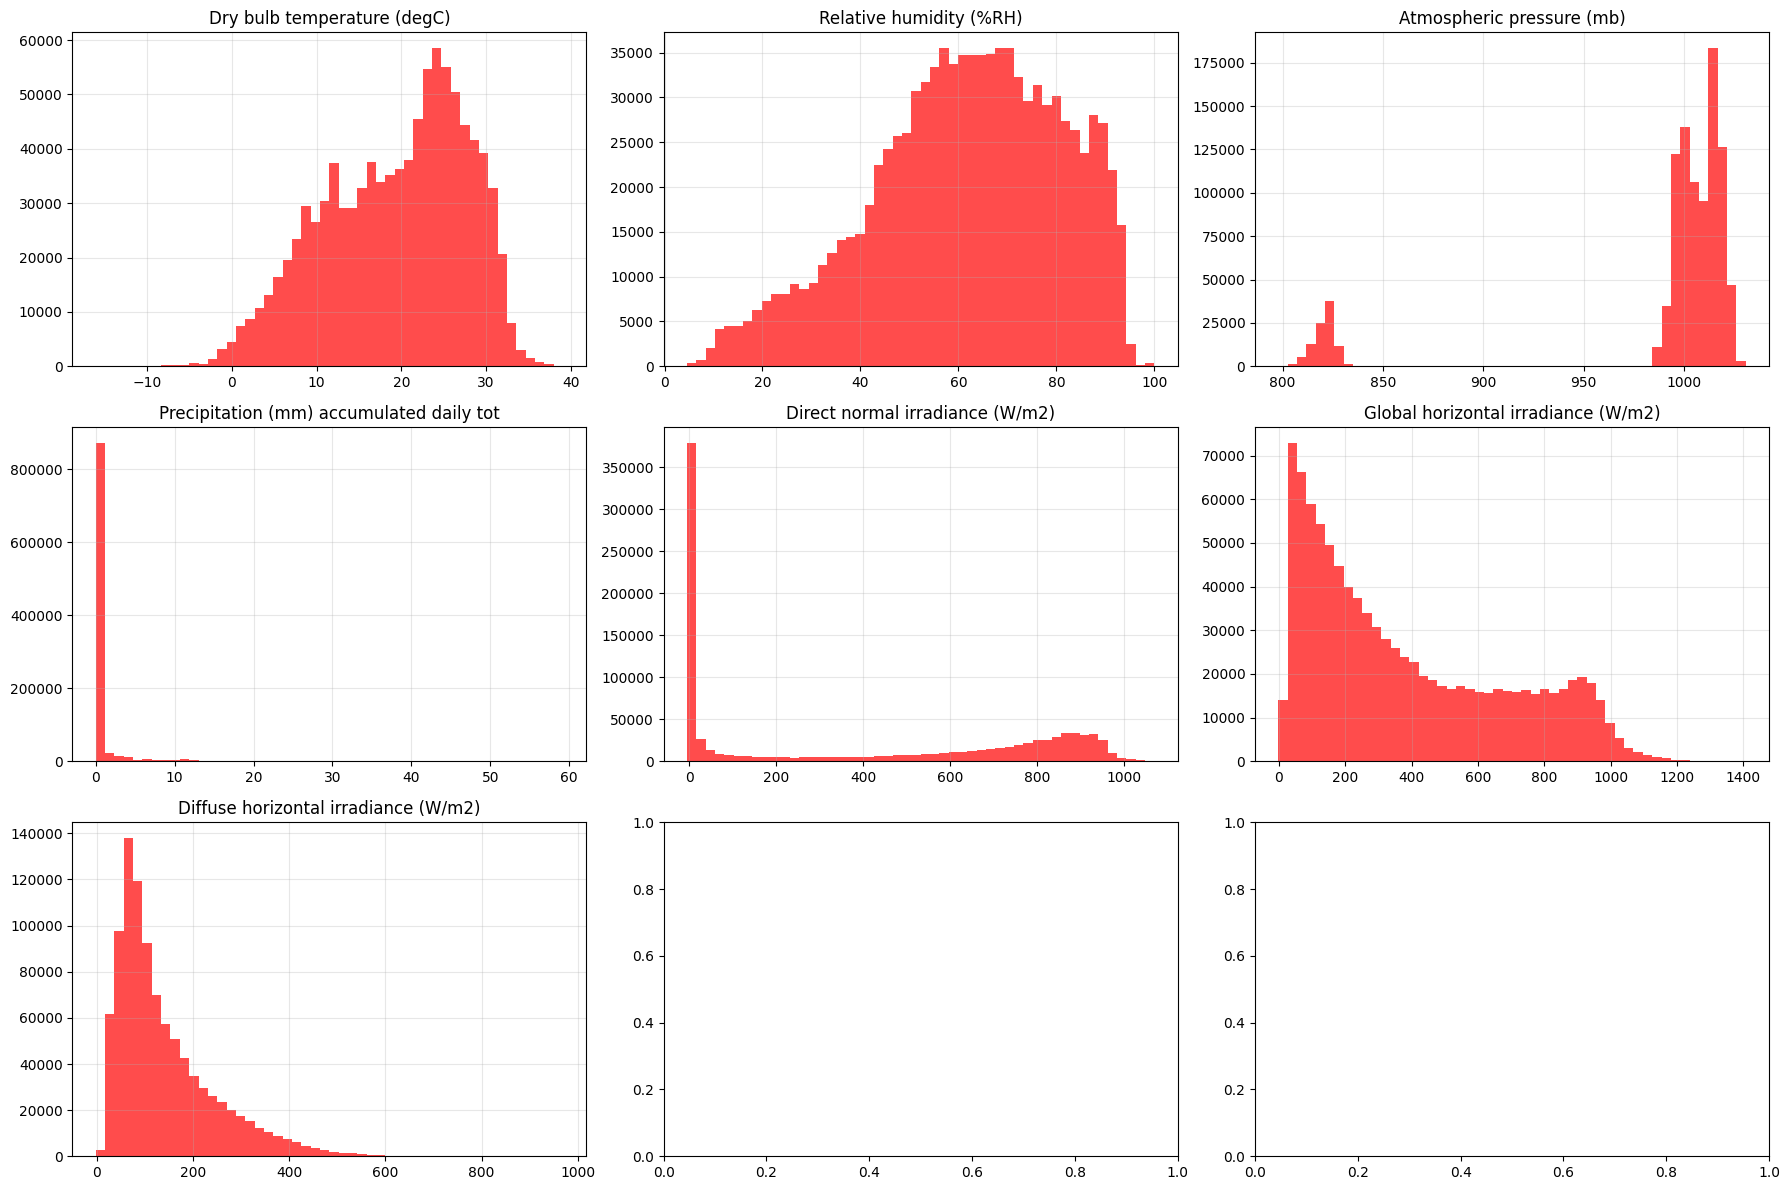

In [ ]:
vars = [
    "Dry bulb temperature (degC)",
    "Relative humidity (%RH)",
    "Atmospheric pressure (mb)",
    "Precipitation (mm) accumulated daily total",
    "Direct normal irradiance (W/m2)",
    "Global horizontal irradiance (W/m2)",
    "Diffuse horizontal irradiance (W/m2)"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, var in enumerate(vars):
    ax = axes[idx]
    dataset_total[var].hist(bins=50, ax=ax, alpha=0.7, color='red')
    ax.set_title(f'{var[:40]}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Una vez eliminados estos outliers, no se ven más a simple vista.


### Análisis de distribuciones

Vamos a comparar las distribuciones de las variables entre los parques.

Parques: ['Eugene' 'Cocoa' 'Golden']


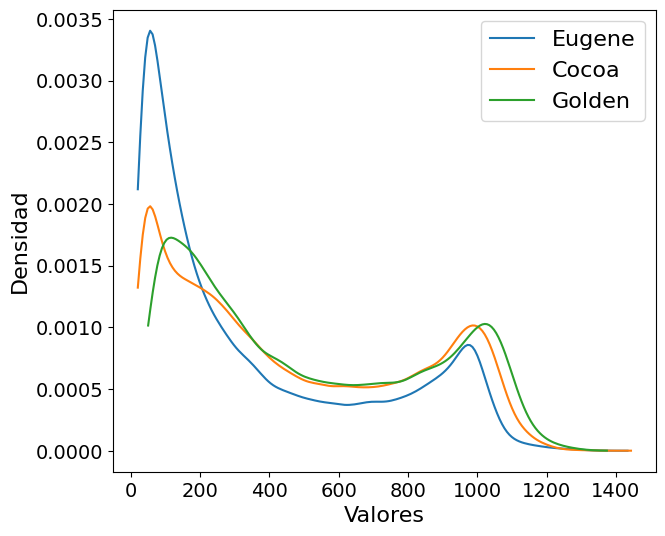

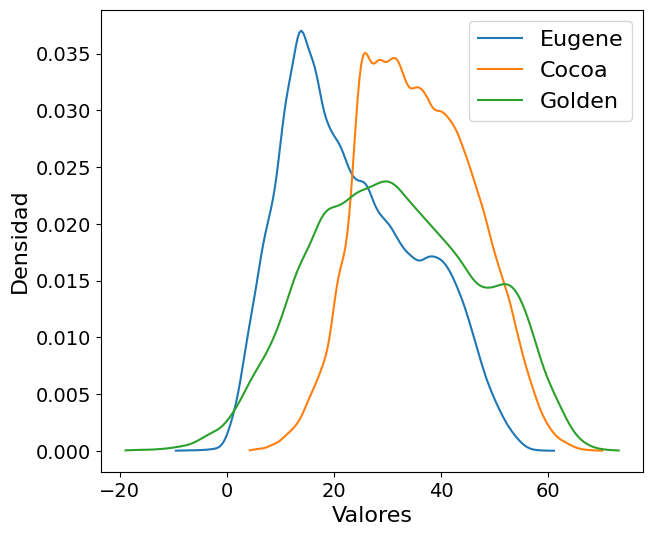

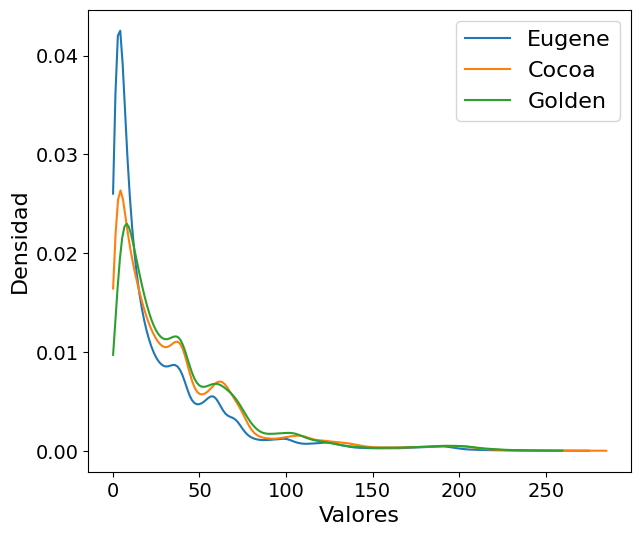

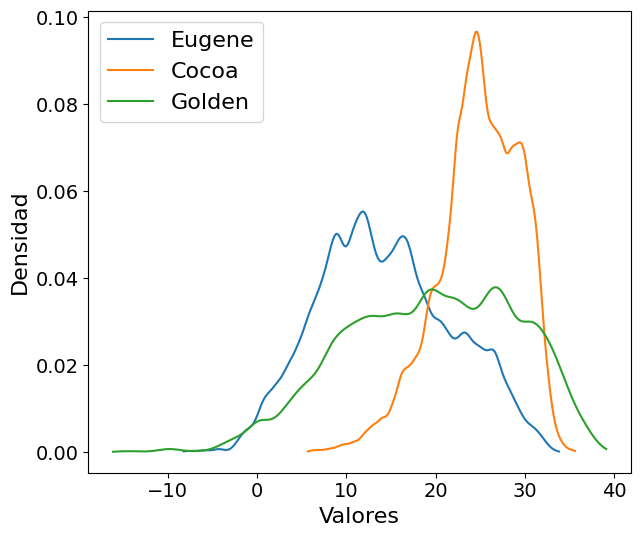

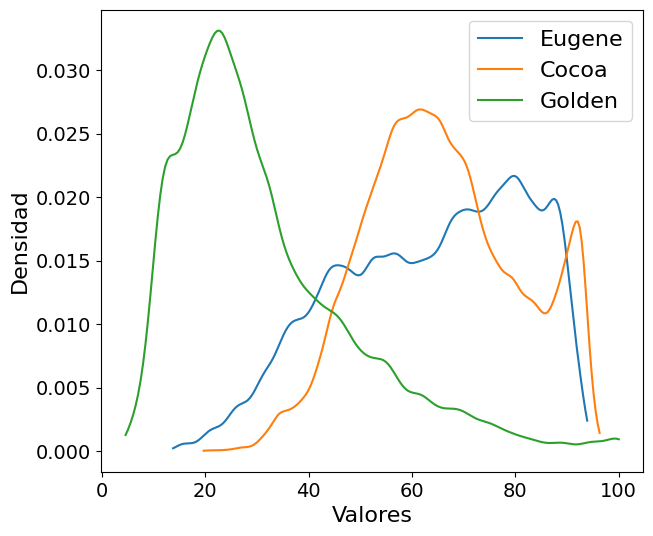

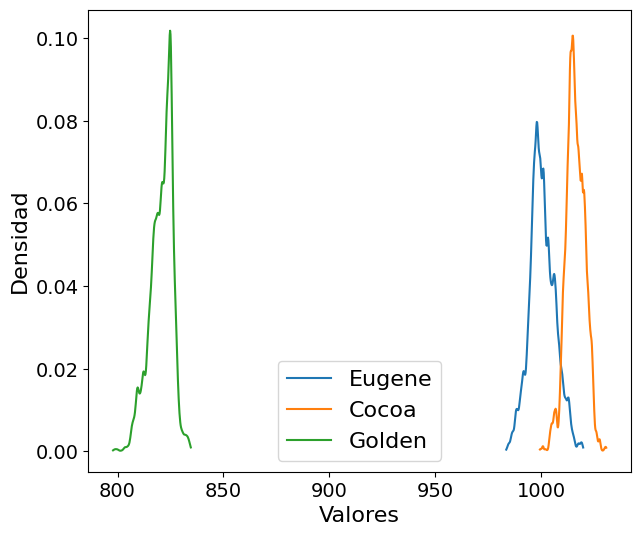

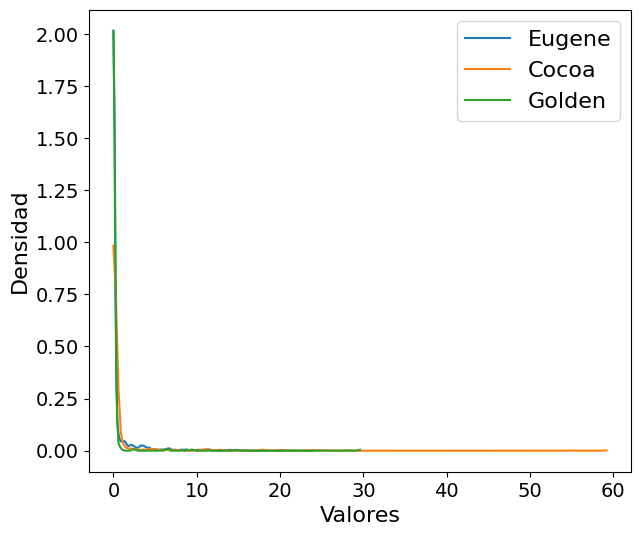

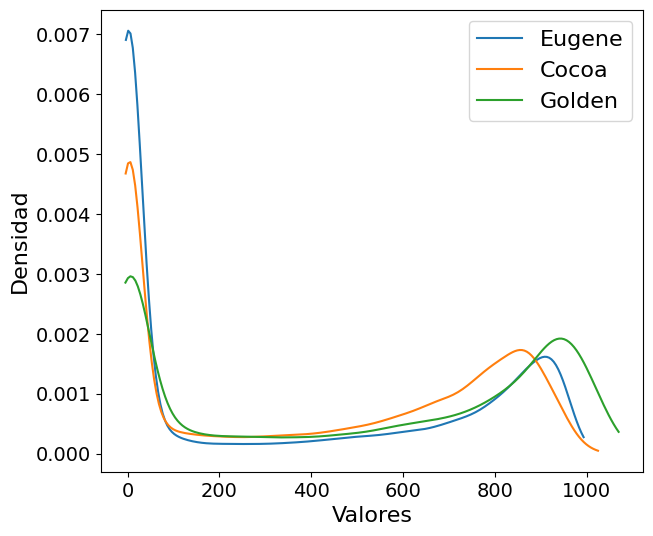

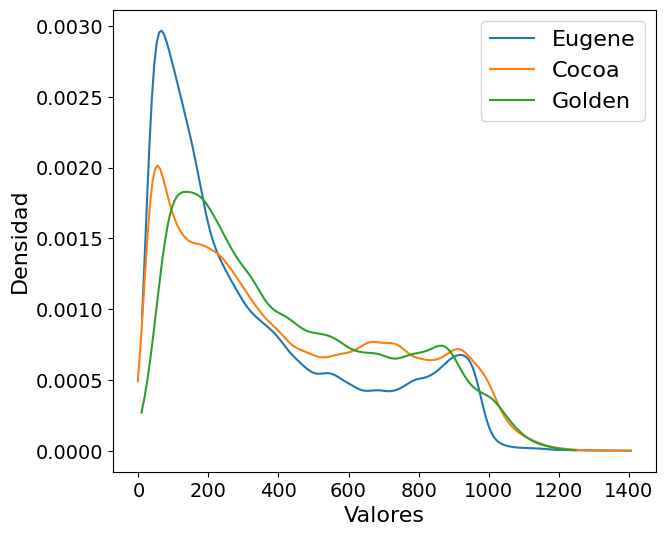

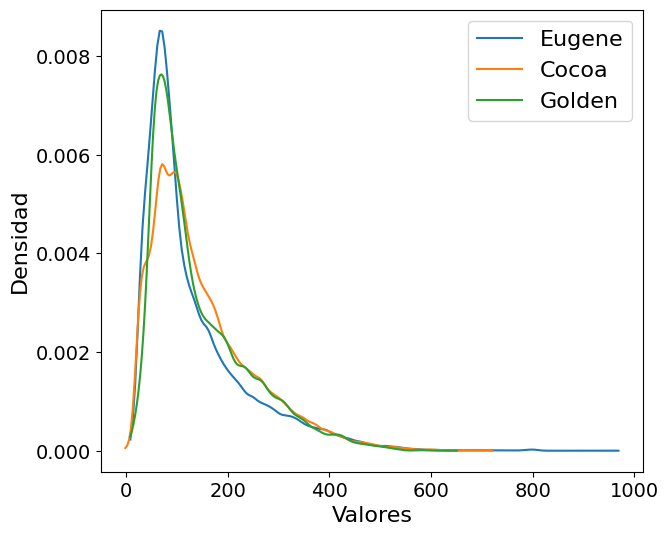

In [ ]:
df = dataset_total.copy()  # Copia para no modificar original

# Solo columnas numéricas + parque
df_clean = df.select_dtypes(include=[np.number])
df_clean["parque_id"] = df["parque_id"]

variables = [col for col in df_clean.columns if col != "parque_id"] # Lista de las variables
parques = df_clean["parque_id"].unique() # Lista de los parques
print("Parques:", parques)

for var in variables: # Para cada variable
    plt.figure(figsize=(7,6))
    for parque in parques: # Para cada parque
        data = df_clean[df_clean["parque_id"] == parque][var].dropna()
        density = stats.gaussian_kde(data) # KDE (Kernel Density Estimation)
        x = np.linspace(data.min(), data.max(), 200)
        y = density(x)
        plt.plot(x, y, label=parque) # Dibujamos la curva
    plt.title(f"Distribución por parque - {var}",fontsize=20)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Valores", fontsize=16)
    plt.ylabel("Densidad", fontsize=16)
    plt.legend(fontsize=16)
    plt.show()

Vamos a comparar las distribuciones de las variables entre los modelos de las placas.

Modelos de panel: ['aSiTandem' 'aSiMicro' 'mSi' 'CIGS' 'HIT' 'xSi' 'CdTe' 'aSiTriple']


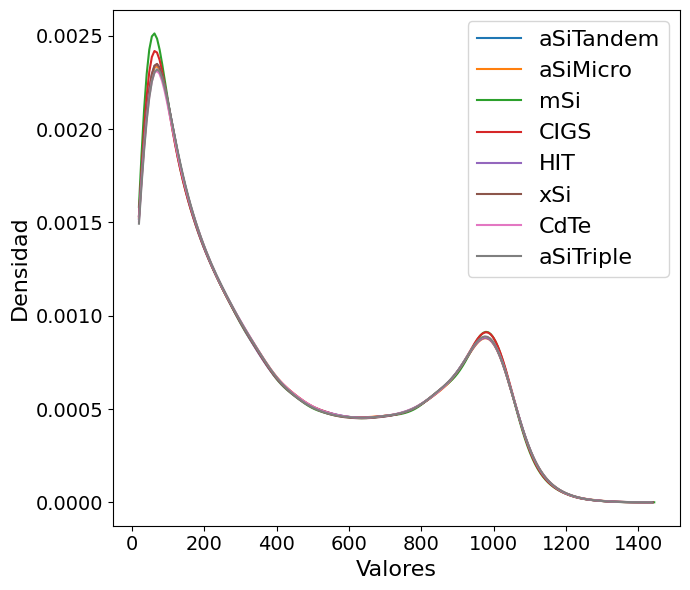

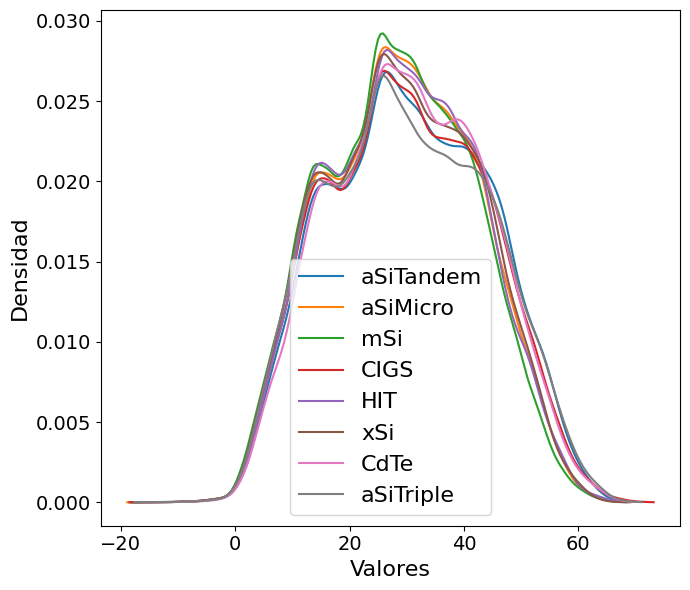

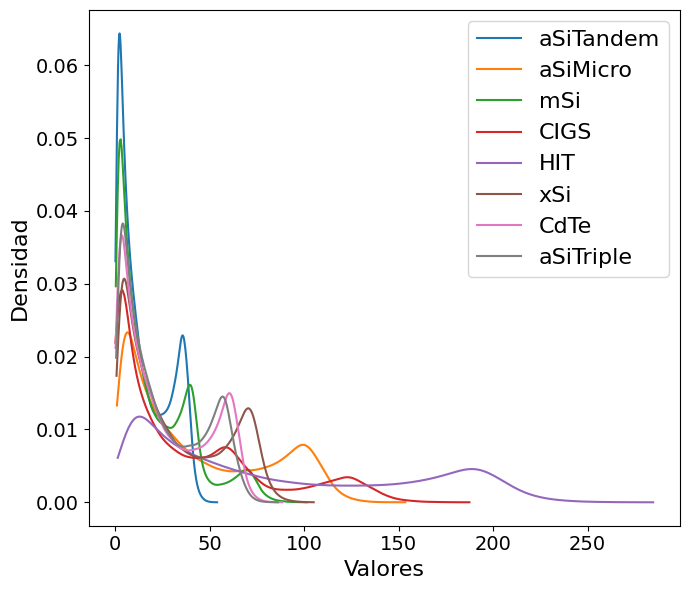

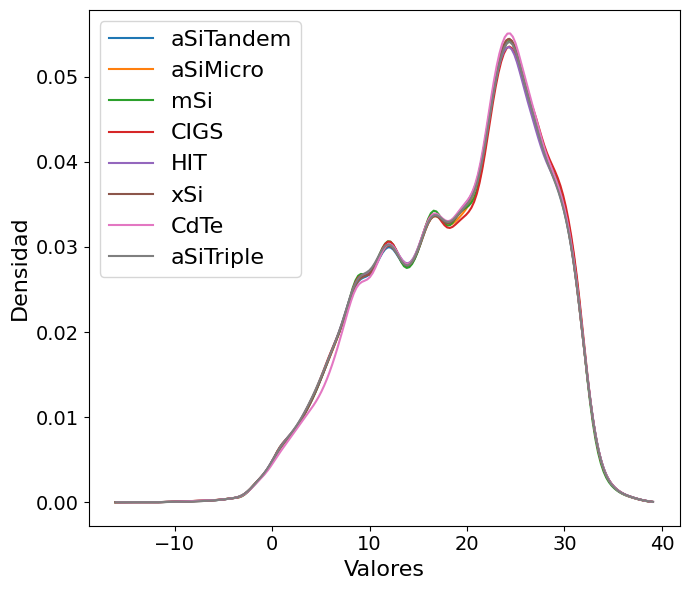

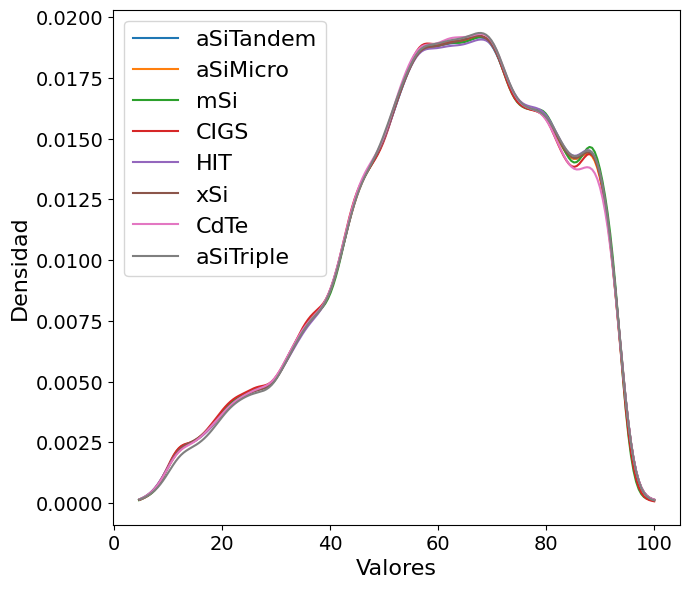

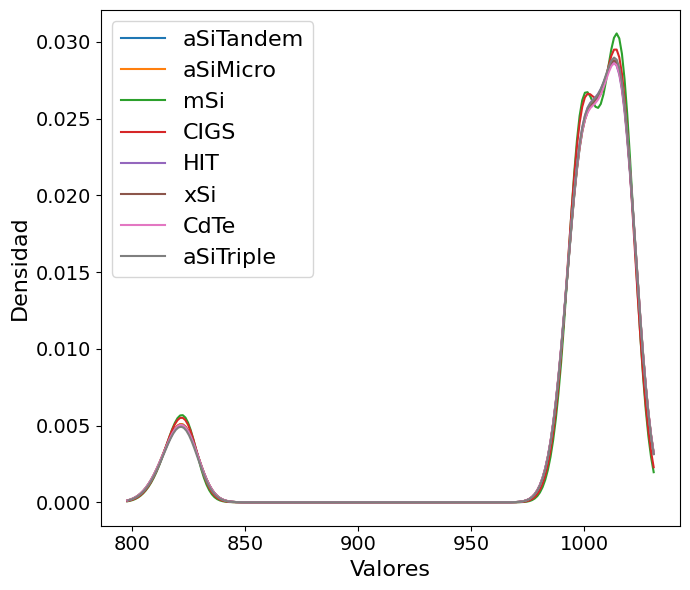

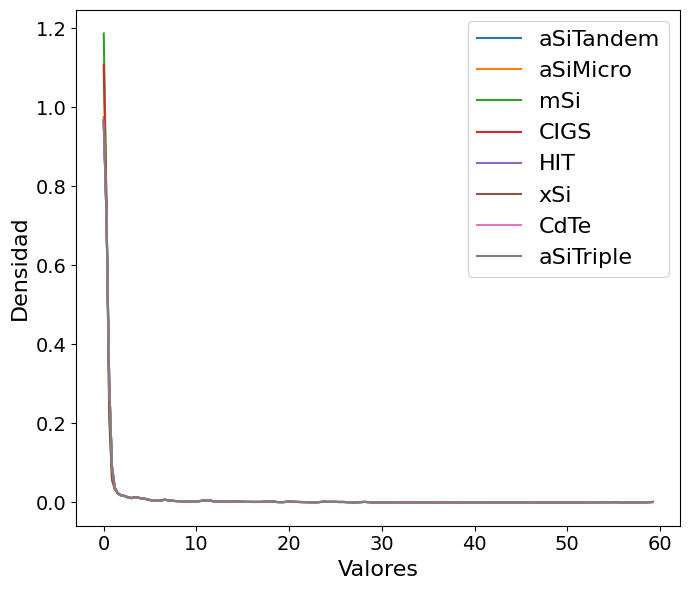

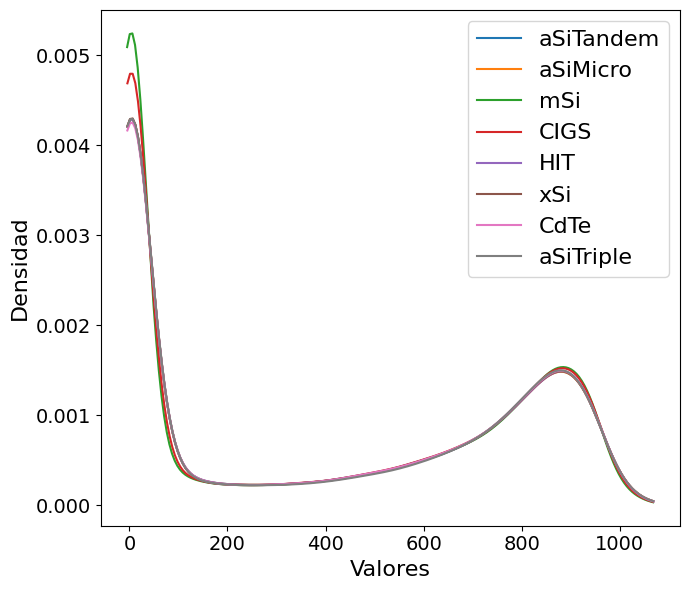

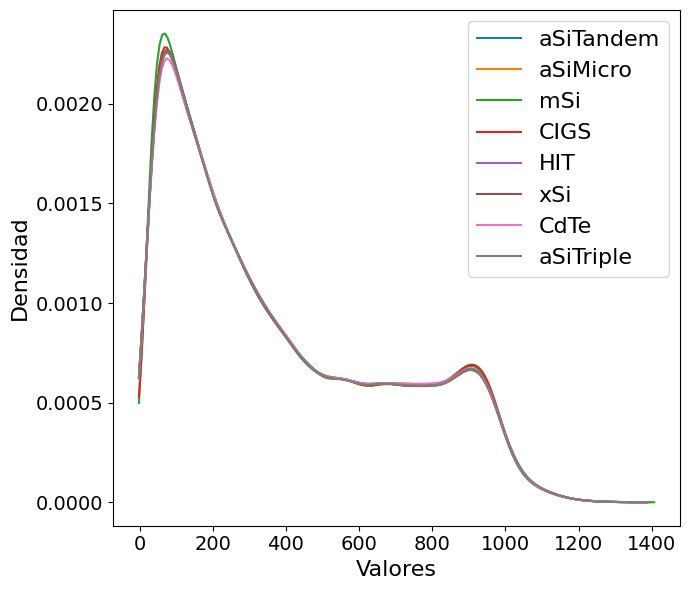

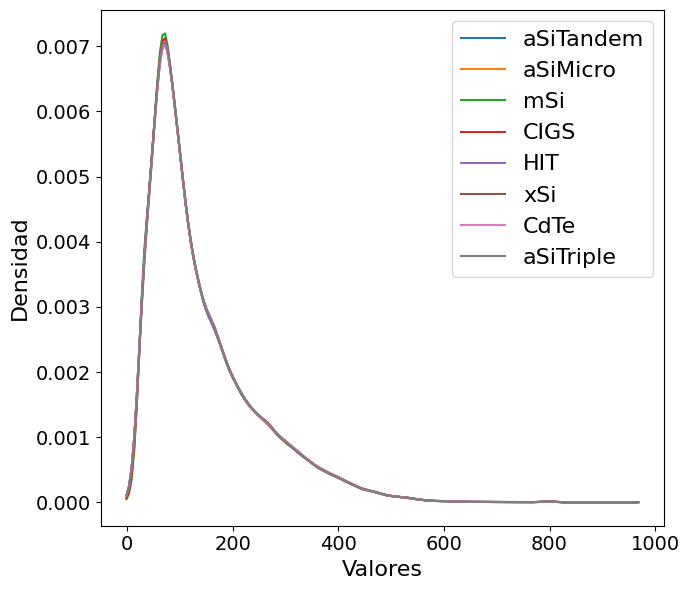

In [ ]:
df = dataset_total.copy() # Copia para no modificar original

# Solo columnas numéricas + modelo panel
df_clean = df.select_dtypes(include=[np.number])
df_clean["modelo_panel"] = df["modelo_panel"]

variables    = [col for col in df_clean.columns if col != "modelo_panel"] # Lista de las variables
modelos      = df_clean["modelo_panel"].unique() # Lista de los modelos
print("Modelos de panel:", modelos)

for var in variables: # Para cada variable
    plt.figure(figsize=(7, 6))
    for modelo in modelos: # Para cada modelo
        data = df_clean[df_clean["modelo_panel"] == modelo][var].dropna()
        density = stats.gaussian_kde(data) # KDE (Kernel Density Estimation)
        x = np.linspace(data.min(), data.max(), 200)
        y = density(x)
        plt.plot(x, y, label=modelo) # Dibujamos la curva
    #plt.title(f"Distribución por modelo de panel - {var}")
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Valores", fontsize=16)
    plt.ylabel("Densidad", fontsize=16)
    plt.legend(fontsize=16)
    plt.tight_layout()
    plt.show()

#### **Los datos de diferentes parques/modelos de placa son id?**

Utilizamos la prueba de Kolmogorov-Smirnof para analizar si las distribuciones entre los parques/modelos son iguales o no. Si se obtiene un p-valor<0.05 tienen distribuciones diferentes, si no tienen distribuciones similares.

**Pontencia**

COMPARACIÓN ENTRE PARQUES
Eugene vs Cocoa -> p-value: 0.000000
Eugene vs Golden -> p-value: 0.000000
Cocoa vs Golden -> p-value: 0.000000


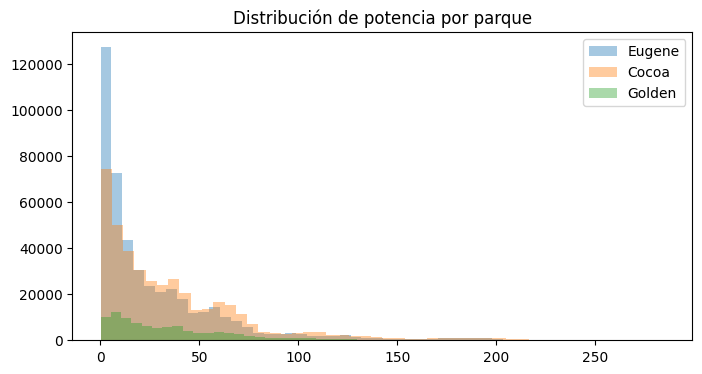

In [ ]:
# Separar datos por parque
datasets = {}
for parque in dataset_total["parque_id"].unique():
    # Filtrar las filas de ese parque específico
    datasets[parque] = pd.DataFrame(dataset_total[dataset_total["parque_id"] == parque]["Pmp (W)"])

print("COMPARACIÓN ENTRE PARQUES")
keys = list(datasets.keys()) # Lista de los parques
for i in range(len(keys)):
    for j in range(i+1, len(keys)): # Evitar comparaciones duplicadas
        d1 = datasets[keys[i]]["Pmp (W)"] # Potencia de un parque
        d2 = datasets[keys[j]]["Pmp (W)"] # Potencia de otro parque
        stat, p = stats.ks_2samp(d1, d2) # Test Kolmogorov-Smirnof para ver si tienen la misma distribución
        print(f"{keys[i]} vs {keys[j]} -> p-value: {p:.6f}")

# Histogramas
plt.figure(figsize=(8,4))
for name, df in datasets.items():
    plt.hist(df["Pmp (W)"], bins=50, alpha=0.4, label=name)
plt.legend()
plt.title("Distribución de potencia por parque")
plt.show()

COMPARACIÓN ENTRE MODELOS
aSiTandem vs aSiMicro -> p-value: 0.000000
aSiTandem vs mSi -> p-value: 0.000000
aSiTandem vs CIGS -> p-value: 0.000000
aSiTandem vs HIT -> p-value: 0.000000
aSiTandem vs xSi -> p-value: 0.000000
aSiTandem vs CdTe -> p-value: 0.000000
aSiTandem vs aSiTriple -> p-value: 0.000000
aSiMicro vs mSi -> p-value: 0.000000
aSiMicro vs CIGS -> p-value: 0.000000
aSiMicro vs HIT -> p-value: 0.000000
aSiMicro vs xSi -> p-value: 0.000000
aSiMicro vs CdTe -> p-value: 0.000000
aSiMicro vs aSiTriple -> p-value: 0.000000
mSi vs CIGS -> p-value: 0.000000
mSi vs HIT -> p-value: 0.000000
mSi vs xSi -> p-value: 0.000000
mSi vs CdTe -> p-value: 0.000000
mSi vs aSiTriple -> p-value: 0.000000
CIGS vs HIT -> p-value: 0.000000
CIGS vs xSi -> p-value: 0.000000
CIGS vs CdTe -> p-value: 0.000000
CIGS vs aSiTriple -> p-value: 0.000000
HIT vs xSi -> p-value: 0.000000
HIT vs CdTe -> p-value: 0.000000
HIT vs aSiTriple -> p-value: 0.000000
xSi vs CdTe -> p-value: 0.000000
xSi vs aSiTriple -> p-

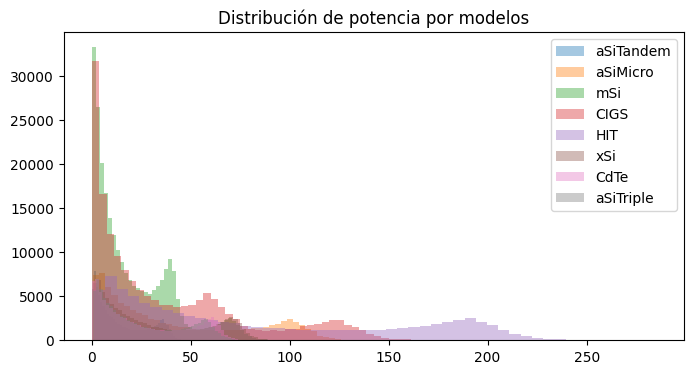

In [ ]:
datasets = {}
for parque in dataset_total["modelo_panel"].unique():
    # Filtrar las filas de ese modelo específico
    datasets[parque] = pd.DataFrame(dataset_total[dataset_total["modelo_panel"] == parque]["Pmp (W)"])

print("COMPARACIÓN ENTRE MODELOS")
keys = list(datasets.keys()) # Lista de los modelos
for i in range(len(keys)):
    for j in range(i+1, len(keys)): # Evitar comparaciones duplicadas
        d1 = datasets[keys[i]]["Pmp (W)"] # Potencia de un modelo
        d2 = datasets[keys[j]]["Pmp (W)"] # Potencia de otro modelo
        stat, p = stats.ks_2samp(d1, d2) # Test Kolmogorov-Smirnof para ver si tienen la misma distribución
        print(f"{keys[i]} vs {keys[j]} -> p-value: {p:.6f}")

# Histogramas
plt.figure(figsize=(8,4))
for name, df in datasets.items():
    plt.hist(df["Pmp (W)"], bins=50, alpha=0.4, label=name)
plt.legend()
plt.title("Distribución de potencia por modelos")
plt.show()

Los p-values de 0.000000 en todas las comparaciones KS indican que todas las distribuciones de potencia son significativamente diferentes entre parques/placas.

**Las demás variables**

COMPARACIÓN DE LA DISTRIBUCiÓN DE LAS VARIABLES ENTRE PARQUES

--- POA irradiance CMP22 pyranometer (W/m2) ---
Eugene vs Cocoa -> p-value: 0.000000
Eugene vs Golden -> p-value: 0.000000
Cocoa vs Golden -> p-value: 0.000000

--- PV module back surface temperature (degC) ---
Eugene vs Cocoa -> p-value: 0.000000
Eugene vs Golden -> p-value: 0.000000
Cocoa vs Golden -> p-value: 0.000000

--- Dry bulb temperature (degC) ---
Eugene vs Cocoa -> p-value: 0.000000
Eugene vs Golden -> p-value: 0.000000
Cocoa vs Golden -> p-value: 0.000000

--- Relative humidity (%RH) ---
Eugene vs Cocoa -> p-value: 0.000000
Eugene vs Golden -> p-value: 0.000000
Cocoa vs Golden -> p-value: 0.000000

--- Atmospheric pressure (mb) ---
Eugene vs Cocoa -> p-value: 0.000000
Eugene vs Golden -> p-value: 0.000000
Cocoa vs Golden -> p-value: 0.000000

--- Precipitation (mm) accumulated daily total ---
Eugene vs Cocoa -> p-value: 0.000000
Eugene vs Golden -> p-value: 0.000000
Cocoa vs Golden -> p-value: 0.000000

--- Dire

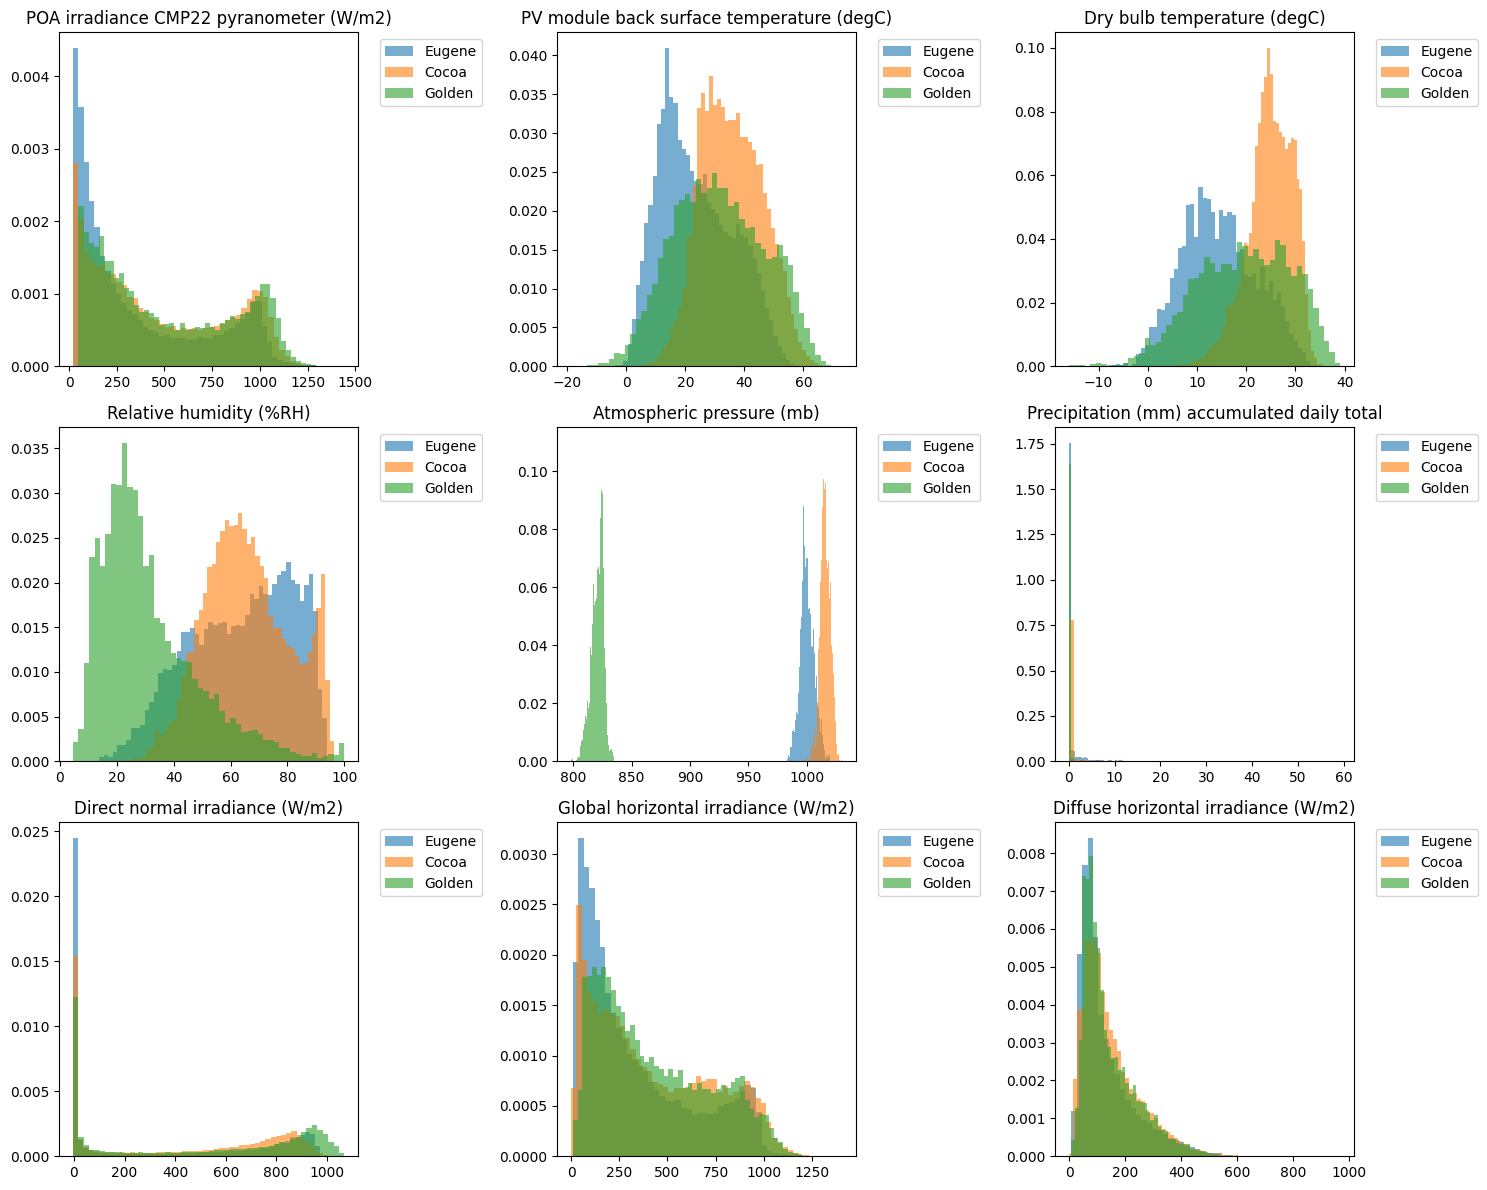

In [ ]:
FEATURES = [
    "POA irradiance CMP22 pyranometer (W/m2)",
    "PV module back surface temperature (degC)",
    "Dry bulb temperature (degC)",
    "Relative humidity (%RH)",
    "Atmospheric pressure (mb)",
    "Precipitation (mm) accumulated daily total",
    "Direct normal irradiance (W/m2)",
    "Global horizontal irradiance (W/m2)",
    "Diffuse horizontal irradiance (W/m2)"
]

# Separar datos por parque
datasets = {}
for parque in dataset_total["parque_id"].unique():
    # Filtrar las filas de ese parque específico
    mask = dataset_total["parque_id"] == parque
    datasets[parque] = dataset_total.loc[mask, FEATURES].copy()

print("COMPARACIÓN DE LA DISTRIBUCiÓN DE LAS VARIABLES ENTRE PARQUES")
keys = list(datasets.keys()) # Lista de los parques
for feature in FEATURES: # Para cada variable
    print(f"\n--- {feature} ---")
    for i in range(len(keys)):
        for j in range(i+1, len(keys)): # Evitar comparaciones duplicadas
            d1 = datasets[keys[i]][feature].dropna() # un parque
            d2 = datasets[keys[j]][feature].dropna() # otro parque
            stat, p = stats.ks_2samp(d1, d2) # Test Kolmogorov-Smirnof para ver si tienen la misma distribución
            print(f"{keys[i]} vs {keys[j]} -> p-value: {p:.6f}")

# Histogramas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for idx, feature in enumerate(FEATURES):
    if idx < 9:
        ax = axes[idx]
        for name, df in datasets.items():
            data = df[feature].dropna()
            if len(data) > 0:
                ax.hist(data, bins=50, alpha=0.6, label=name, density=True)
        ax.set_title(feature)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Los p-values de 0.000000 en todas las comparaciones KS indican que todas las distribuciones de las variables son significativamente diferentes entre parques.

In [ ]:
FEATURES = [
    "POA irradiance CMP22 pyranometer (W/m2)",
    "PV module back surface temperature (degC)",
    "Dry bulb temperature (degC)",
    "Relative humidity (%RH)",
    "Atmospheric pressure (mb)",
    "Precipitation (mm) accumulated daily total",
    "Direct normal irradiance (W/m2)",
    "Global horizontal irradiance (W/m2)",
    "Diffuse horizontal irradiance (W/m2)"
]

# Separar datos por modelo
datasets = {}
for modelo in dataset_total["modelo_panel"].unique():
    # Filtrar las filas de ese modelo específico
    mask = dataset_total["modelo_panel"] == modelo
    datasets[modelo] = dataset_total.loc[mask, FEATURES].copy()

print("COMPARACIÓN DE LA DISTRIBUCIÓN DE LAS VARIABLES ENTRE MODELOS")
keys = list(datasets.keys()) # Lista de los modelos
for feature in FEATURES: # Para cada variable
    print(f"\n--- {feature} ---")
    for i in range(len(keys)):
        for j in range(i+1, len(keys)): # Evitar comparaciones duplicadas
            d1 = datasets[keys[i]][feature].dropna() # un modelo
            d2 = datasets[keys[j]][feature].dropna() # otro modelo
            stat, p = stats.ks_2samp(d1, d2)
            print(f"{keys[i]} vs {keys[j]} -> p-value: {p:.6f}")

COMPARACIÓN DE LA DISTRIBUCIÓN DE LAS VARIABLES ENTRE MODELOS

--- POA irradiance CMP22 pyranometer (W/m2) ---
aSiTandem vs aSiMicro -> p-value: 1.000000
aSiTandem vs mSi -> p-value: 0.997137
aSiTandem vs CIGS -> p-value: 0.343701
aSiTandem vs HIT -> p-value: 0.999737
aSiTandem vs xSi -> p-value: 0.998892
aSiTandem vs CdTe -> p-value: 0.725783
aSiTandem vs aSiTriple -> p-value: 0.667415
aSiMicro vs mSi -> p-value: 0.974992
aSiMicro vs CIGS -> p-value: 0.405535
aSiMicro vs HIT -> p-value: 0.995172
aSiMicro vs xSi -> p-value: 0.988795
aSiMicro vs CdTe -> p-value: 0.821126
aSiMicro vs aSiTriple -> p-value: 0.477191
mSi vs CIGS -> p-value: 0.019281
mSi vs HIT -> p-value: 0.999999
mSi vs xSi -> p-value: 1.000000
mSi vs CdTe -> p-value: 0.135807
mSi vs aSiTriple -> p-value: 0.155480
CIGS vs HIT -> p-value: 0.149205
CIGS vs xSi -> p-value: 0.121009
CIGS vs CdTe -> p-value: 0.965098
CIGS vs aSiTriple -> p-value: 0.914769
HIT vs xSi -> p-value: 1.000000
HIT vs CdTe -> p-value: 0.293688
HIT vs a

La temperatura del módulo (p=0.000) distingue perfectamente todas los modelos PV por sus distintos coeficientes térmicos. POA irradiance es idéntica (p≈1.0) entre todos → excelente control experimental, las diferencias de potencia son solo por el modelo. Precipitación/humedad homogéneas confirman mismo microclima.

# 3. MODELO BASELINE

## Redes neuronales

Los primeros modelos que hemos probado son unas redes neuronales simples.

Vamos a utilizar el nombre del parque y el nombre de la placa. Pero primero los hemos codificado utilizando LabelEncoder.

In [ ]:
le_parque = LabelEncoder()
le_panel  = LabelEncoder()

dataset_total["parque_enc"] = le_parque.fit_transform(dataset_total["parque_id"])
dataset_total["panel_enc"]  = le_panel.fit_transform(dataset_total["panel_id"])
dataset_total["modelo_panel_enc"]  = le_panel.fit_transform(dataset_total["modelo_panel"])

In [ ]:
df_model=dataset_total.drop(columns=["parque_id","panel_id","modelo_panel","modelo_panel_enc"])

In [ ]:
X = df_model.drop(columns=["Pmp (W)"])
y = df_model["Pmp (W)"] # Variable objetivo

Separamos el dataset en train 60%, test 20% y val 20%.

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(577464, 11) (192488, 11) (192488, 11)


Escalamos los datos.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_scaler = StandardScaler()  # Para TARGETS (salidas)
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = y_scaler.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = y_scaler.transform(y_test.values.reshape(-1, 1))

In [ ]:
np.mean(X_train_scaled, axis=0) # Media

array([ 3.39605231e-17, -3.17850809e-16, -1.64450142e-16, -1.28287106e-16,
        7.57366422e-15,  1.04748526e-16,  1.07270957e-16, -4.93658039e-17,
       -6.91022818e-17,  1.60205076e-17,  9.95190981e-17])

In [ ]:
np.std(X_train_scaled, axis=0) # Desviación estándar

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Convertimos los datos en tensores de PyTorch.

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1,1)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1,1)

### Diseño de los modelos

Definimos la arquitectura del primer modelo que hemos probado. 4 capas lineales: 11 → 64 → 32 → 16 → 1, con función de activación ReLU después de cada capa.

In [ ]:
class PVModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            # Capa 1: 11 entradas -> 64 neuronas ocultas
            nn.Linear(11, 64),
            nn.ReLU(),
            # Capa 2: 64 -> 32 neuronas
            nn.Linear(64, 32),
            nn.ReLU(),
            # Capa 3: 32 -> 16 neurona
            nn.Linear(32, 16),
            nn.ReLU(),
            # Capa de salida: 16 -> 1
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

Definimos la arquitectura del segundo modelo, es una red neuronal mejorada con BatchNorm y Dropout.

In [ ]:
class PVModelV2(nn.Module):

    def __init__(self, input_size=11):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 64), # Capa lineal
            nn.BatchNorm1d(64), # Normaliza activaciones → estabilidad en gradientes
            nn.ReLU(), # Función de activación
            nn.Dropout(0.2), # Dropout 20% → previene overfitting

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
model = PVModel()
print(model)

model2 = PVModelV2()
print(model2)

PVModel(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
PVModelV2(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_feature

Predicciones con las primero 5 muestras del conjunto de entrenamiento.

In [ ]:
model(X_train_tensor[:5])

tensor([[-0.2675],
        [-0.2646],
        [-0.2570],
        [-0.2464],
        [-0.2047]], grad_fn=<AddmmBackward0>)

In [ ]:
model2(X_train_tensor[:5])

tensor([[-0.3370],
        [-0.1563],
        [-0.1345],
        [-0.0192],
        [-0.3187]], grad_fn=<AddmmBackward0>)

In [ ]:
criterion = nn.MSELoss() # Definir función de pérdida para regresión (Error Cuadrático Medio)

# Optimizador Adam con tasa de aprendizaje
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Se crean los DataLoader.

In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1024
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024
)

### ML FLOW y entrenar los modelos

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import mlflow

In [ ]:
drive_path = "/content/drive/MyDrive/mlruns" # Guardamos la carpeta mlruns en drive
os.makedirs(drive_path, exist_ok=True)

mlflow.set_tracking_uri(f"file:{drive_path}")
mlflow.set_experiment("PV_Power_ENTRENAMIENTO_FINAL2")

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/11 14:54:22 INFO mlflow.tracking.fluent: Experiment with name 'PV_Power_ENTRENAMIENTO_FINAL2' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///content/drive/MyDrive/mlruns/881841553248573889', creation_time=1775919262981, experiment_id='881841553248573889', last_update_time=1775919262981, lifecycle_stage='active', name='PV_Power_ENTRENAMIENTO_FINAL2', tags={}, trace_location=None, workspace='default'>

Vamos a probar diferentes arquitecturas para elegir el mejor modelo.

Primer modelo.

In [ ]:
class PVModel(nn.Module):

    def __init__(self, layers_sizes, input_size=11):
        super().__init__()

        layers = []

        for size in layers_sizes:
            layers.append(nn.Linear(input_size, size)) # Capa lineal
            layers.append(nn.ReLU()) # Activación
            input_size = size # Actualiza para siguiente capa

        layers.append(nn.Linear(input_size, 1)) # Capa de salida

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

Segundo modelo.

In [ ]:
class PVModelV2(nn.Module):

    def __init__(self, layers_sizes,dropout, input_size=11):
        super().__init__()

        layers = []

        for size in layers_sizes:
            layers.append(nn.Linear(input_size, size)) # Capa lineal
            layers.append(nn.BatchNorm1d(size)) # Batch Normalization
            layers.append(nn.ReLU()) # Activación
            layers.append(nn.Dropout(dropout)) # Dropout
            input_size = size # Actualiza para siguiente capa

        layers.append(nn.Linear(input_size, 1)) # Capa de salida

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

Definimos una función para evaluar el modelo.

In [ ]:
def evaluate(model, loader, criterion):
    model.eval() # Modo evaluación
    total_loss = 0

    # Desactiva gradientes
    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_pred = model(X_batch) # Predicciones
            loss = criterion(y_pred, y_batch) # MSE por batch
            total_loss += loss.item() # Suma loss
    return total_loss / len(loader)

Función para calcular las métricas.

In [ ]:
def evaluate_metrics(model, loader):
    model.eval() # Modo evaluación

    y_true = [] # Lista para guardar valores reales
    y_pred = [] # Lista para guardar predicciones del modelo

    # Desactiva gradientes
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch) # Predicciones
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return mse, rmse, mae, r2

Función para entrenar el modelo.

In [ ]:
def train_model(arch, lr, epochs, model,train_loader, val_loader, dropout=0):
    criterion = nn.MSELoss() # función de pérdida MSE
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # Optimizador Adam

    best_val_loss = float("inf")
    patience = 10 # Paciencia del early stopping
    counter = 0 # Contador de epochs sin mejora

    with mlflow.start_run(): # MLflow: Inicia experiment tracking
        # Log hiperparámetros
        mlflow.log_param("arquitectura", str(arch))
        mlflow.log_param("lr", lr)
        mlflow.log_param("dropout", dropout)

        # ENTRENAMIENTO
        for epoch in range(epochs):
            model.train() # Modo entrenamiento
            total_loss = 0

            for X_batch, y_batch in train_loader: # Itera batches de entrenamiento
                y_pred = model(X_batch) # Predicción
                loss = criterion(y_pred, y_batch) # Calcula la pérdida
                optimizer.zero_grad() # Limpia gradientes previos
                loss.backward() # Backpropagation
                optimizer.step() # Actualiza pesos
                total_loss += loss.item()

            train_loss = total_loss / len(train_loader) # Loss promedio train
            # VALIDACIÓN
            val_loss = evaluate(model, val_loader, criterion) # Loss validación
            train_mse, train_rmse, train_mae, train_r2 = evaluate_metrics(model, train_loader) # Métricas train
            val_mse, val_rmse, val_mae, val_r2 = evaluate_metrics(model, val_loader) # Métricas validación

            # LOGGING MLFLOW (métricas)
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("val_loss", val_loss, step=epoch)
            mlflow.log_metric("train_rmse", train_rmse, step=epoch)
            mlflow.log_metric("val_rmse", val_rmse, step=epoch)
            mlflow.log_metric("train_mae", train_mae, step=epoch)
            mlflow.log_metric("val_mae", val_mae, step=epoch)
            mlflow.log_metric("train_r2", train_r2, step=epoch)
            mlflow.log_metric("val_r2", val_r2, step=epoch)

            print(f"""
Epoch {epoch+1}
Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}
Val RMSE: {val_rmse:.4f} | MAE: {val_mae:.4f} | R2: {val_r2:.4f}
""")
            # EARLY STOPPING
            if val_loss < best_val_loss:
                best_val_loss = val_loss # Actualiza mejor loss
                torch.save(model.state_dict(), "best_model.pt") # Guarda mejor modelo
                counter = 0 # Resetea contador
            else:
                counter += 1

            if counter >= patience: # Si se acaba la paciencia si activa early stopping
                print(f"Early stopping en epoch {epoch+1}")
                break

        # LOG MODELO FINAL
        mlflow.pytorch.log_model(model, "model")

    return model

Definimos las arquitecturas, y valores de lr y dropout que vamos a probar.

In [ ]:
arquitecturas = [
    [64, 32, 16],
    [128, 64, 32],
    [256, 128, 64]
]

learning_rates = [0.001, 0.0005]

dropouts = [0.1, 0.2]

epochs = 100

Entrenamos el primer modelo probando todas las combinaciones.

In [ ]:
for arch in arquitecturas:
    for lr in learning_rates:
        model = PVModel(arch)
        print(f"\nEntrenando modelo {arch} con lr={lr}")
        train_model(arch, lr, epochs,model,train_loader,val_loader)


Entrenando modelo [64, 32, 16] con lr=0.001

Epoch 1
Train Loss: 841.3348 | Val Loss: 530.3506
Val RMSE: 23.0292 | MAE: 13.9081 | R2: 0.6259


Epoch 2
Train Loss: 386.2938 | Val Loss: 277.3745
Val RMSE: 16.6545 | MAE: 10.3584 | R2: 0.8043


Epoch 3
Train Loss: 240.1550 | Val Loss: 206.0398
Val RMSE: 14.3541 | MAE: 8.5569 | R2: 0.8546


Epoch 4
Train Loss: 165.9230 | Val Loss: 125.7118
Val RMSE: 11.2121 | MAE: 6.5992 | R2: 0.9113


Epoch 5
Train Loss: 93.8799 | Val Loss: 70.2706
Val RMSE: 8.3828 | MAE: 4.9043 | R2: 0.9504


Epoch 6
Train Loss: 57.7730 | Val Loss: 49.2456
Val RMSE: 7.0175 | MAE: 3.9998 | R2: 0.9653


Epoch 7
Train Loss: 43.0241 | Val Loss: 38.1700
Val RMSE: 6.1782 | MAE: 3.5518 | R2: 0.9731


Epoch 8
Train Loss: 34.8880 | Val Loss: 31.4536
Val RMSE: 5.6084 | MAE: 3.2648 | R2: 0.9778


Epoch 9
Train Loss: 28.4743 | Val Loss: 25.6557
Val RMSE: 5.0652 | MAE: 2.9862 | R2: 0.9819


Epoch 10
Train Loss: 23.5521 | Val Loss: 21.6117
Val RMSE: 4.6489 | MAE: 2.7630 | R2: 0.9848



2026/03/23 13:21:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 13:21:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.



Epoch 69
Train Loss: 1.8748 | Val Loss: 1.8034
Val RMSE: 1.3429 | MAE: 0.8375 | R2: 0.9987

Early stopping en epoch 69


2026/03/23 13:21:54 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/23 13:22:05 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [64, 32, 16] con lr=0.0005

Epoch 1
Train Loss: 1002.2441 | Val Loss: 562.2641
Val RMSE: 23.7120 | MAE: 14.6579 | R2: 0.6033


Epoch 2
Train Loss: 529.2637 | Val Loss: 487.0277
Val RMSE: 22.0686 | MAE: 13.4737 | R2: 0.6564


Epoch 3
Train Loss: 377.4337 | Val Loss: 289.1875
Val RMSE: 17.0055 | MAE: 10.5300 | R2: 0.7960


Epoch 4
Train Loss: 250.3601 | Val Loss: 227.9513
Val RMSE: 15.0980 | MAE: 8.8283 | R2: 0.8392


Epoch 5
Train Loss: 202.6032 | Val Loss: 181.9904
Val RMSE: 13.4904 | MAE: 7.8851 | R2: 0.8716


Epoch 6
Train Loss: 159.3156 | Val Loss: 140.5640
Val RMSE: 11.8560 | MAE: 6.9935 | R2: 0.9008


Epoch 7
Train Loss: 123.0163 | Val Loss: 109.4450
Val RMSE: 10.4616 | MAE: 6.1717 | R2: 0.9228


Epoch 8
Train Loss: 96.2806 | Val Loss: 86.2620
Val RMSE: 9.2877 | MAE: 5.6119 | R2: 0.9391


Epoch 9
Train Loss: 77.1377 | Val Loss: 69.6074
Val RMSE: 8.3431 | MAE: 5.0615 | R2: 0.9509


Epoch 10
Train Loss: 62.5042 | Val Loss: 57.5088
Val RMSE: 7.5835 | MAE: 4.6595 | 

...


Entrenando modelo [128, 64, 32] con lr=0.0005

Epoch 1
Train Loss: 813.1678 | Val Loss: 537.8253
Val RMSE: 23.1909 | MAE: 13.9777 | R2: 0.6206


Epoch 2
Train Loss: 446.9781 | Val Loss: 337.3375
Val RMSE: 18.3667 | MAE: 10.6219 | R2: 0.7620


Epoch 3
Train Loss: 267.1122 | Val Loss: 206.6359
Val RMSE: 14.3748 | MAE: 8.5567 | R2: 0.8542


Epoch 4
Train Loss: 162.9937 | Val Loss: 132.7075
Val RMSE: 11.5199 | MAE: 7.0285 | R2: 0.9064


Epoch 5
Train Loss: 108.3695 | Val Loss: 88.5104
Val RMSE: 9.4080 | MAE: 5.5256 | R2: 0.9376


Epoch 6
Train Loss: 74.4953 | Val Loss: 63.9318
Val RMSE: 7.9957 | MAE: 4.6930 | R2: 0.9549


Epoch 7
Train Loss: 53.1320 | Val Loss: 45.5280
Val RMSE: 6.7474 | MAE: 4.0799 | R2: 0.9679


Epoch 8
Train Loss: 38.2056 | Val Loss: 32.3006
Val RMSE: 5.6834 | MAE: 3.4898 | R2: 0.9772


Epoch 9
Train Loss: 27.2670 | Val Loss: 23.1003
Val RMSE: 4.8063 | MAE: 2.9430 | R2: 0.9837


Epoch 10
Train Loss: 18.9471 | Val Loss: 16.2539
Val RMSE: 4.0316 | MAE: 2.3756 | R2: 0.988

2026/03/23 14:00:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/23 14:00:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/23 14:00:26 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Epoch 43
Train Loss: 1.2558 | Val Loss: 1.3414
Val RMSE: 1.1581 | MAE: 0.7117 | R2: 0.9991

Early stopping en epoch 43


2026/03/23 14:00:31 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



Entrenando modelo [256, 128, 64] con lr=0.001

Epoch 1
Train Loss: 589.3715 | Val Loss: 319.0688
Val RMSE: 17.8624 | MAE: 9.9990 | R2: 0.7749


Epoch 2
Train Loss: 124.3364 | Val Loss: 42.3005
Val RMSE: 6.5039 | MAE: 3.4819 | R2: 0.9702


Epoch 3
Train Loss: 29.1331 | Val Loss: 20.6876
Val RMSE: 4.5484 | MAE: 2.5071 | R2: 0.9854


Epoch 4
Train Loss: 12.4975 | Val Loss: 6.6910
Val RMSE: 2.5867 | MAE: 1.4541 | R2: 0.9953


Epoch 5
Train Loss: 4.3645 | Val Loss: 2.7235
Val RMSE: 1.6503 | MAE: 1.0068 | R2: 0.9981


Epoch 6
Train Loss: 2.3553 | Val Loss: 2.3930
Val RMSE: 1.5469 | MAE: 0.9509 | R2: 0.9983


Epoch 7
Train Loss: 1.7971 | Val Loss: 2.1007
Val RMSE: 1.4494 | MAE: 0.9507 | R2: 0.9985


Epoch 8
Train Loss: 1.6485 | Val Loss: 1.4749
Val RMSE: 1.2144 | MAE: 0.7575 | R2: 0.9990


Epoch 9
Train Loss: 1.4561 | Val Loss: 2.1476
Val RMSE: 1.4655 | MAE: 0.9627 | R2: 0.9985


Epoch 10
Train Loss: 1.4469 | Val Loss: 1.3448
Val RMSE: 1.1596 | MAE: 0.7540 | R2: 0.9991


Epoch 11
Train Loss:

Entrenamos el segundo modelo probando todas las combinaciones.

In [ ]:
for arch in arquitecturas:
    for lr in learning_rates:
        for dropout in dropouts:
            model = PVModelV2(arch, dropout=dropout)
            print(f"\nEntrenando modelo {arch} | lr={lr} | dropout={dropout}")
            train_model(arch, lr, epochs, model, train_loader,val_loader, dropout)


Entrenando modelo [64, 32, 16] | lr=0.001 | dropout=0.1

Epoch 1
Train Loss: 1895.6298 | Val Loss: 1179.1085
Val RMSE: 34.3380 | MAE: 22.9408 | R2: 0.1682


Epoch 2
Train Loss: 480.2727 | Val Loss: 114.4874
Val RMSE: 10.6999 | MAE: 6.6242 | R2: 0.9192


Epoch 3
Train Loss: 145.6087 | Val Loss: 45.7663
Val RMSE: 6.7651 | MAE: 4.3991 | R2: 0.9677


Epoch 4
Train Loss: 119.2769 | Val Loss: 36.4408
Val RMSE: 6.0366 | MAE: 3.5315 | R2: 0.9743


Epoch 5
Train Loss: 104.6792 | Val Loss: 34.8910
Val RMSE: 5.9069 | MAE: 3.4931 | R2: 0.9754


Epoch 6
Train Loss: 95.7827 | Val Loss: 23.7126
Val RMSE: 4.8696 | MAE: 3.1293 | R2: 0.9833


Epoch 7
Train Loss: 86.3575 | Val Loss: 18.1387
Val RMSE: 4.2590 | MAE: 2.6386 | R2: 0.9872


Epoch 8
Train Loss: 80.7795 | Val Loss: 21.4439
Val RMSE: 4.6307 | MAE: 2.8200 | R2: 0.9849


Epoch 9
Train Loss: 77.2582 | Val Loss: 19.4108
Val RMSE: 4.4057 | MAE: 2.6549 | R2: 0.9863


Epoch 10
Train Loss: 75.2125 | Val Loss: 11.7202
Val RMSE: 3.4235 | MAE: 2.3773 | R2

2026/03/26 07:26:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Epoch 19
Train Loss: 63.3496 | Val Loss: 13.0543
Val RMSE: 3.6131 | MAE: 2.2774 | R2: 0.9908

Early stopping en epoch 19


2026/03/26 07:26:37 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 07:26:37 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/26 07:26:47 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to mak


Entrenando modelo [64, 32, 16] | lr=0.001 | dropout=0.2

Epoch 1
Train Loss: 1945.5228 | Val Loss: 1210.7918
Val RMSE: 34.7963 | MAE: 22.8401 | R2: 0.1458


Epoch 2
Train Loss: 538.0256 | Val Loss: 146.9569
Val RMSE: 12.1225 | MAE: 7.8955 | R2: 0.8963


Epoch 3
Train Loss: 212.0879 | Val Loss: 73.9814
Val RMSE: 8.6012 | MAE: 5.5016 | R2: 0.9478


Epoch 4
Train Loss: 179.9129 | Val Loss: 53.1490
Val RMSE: 7.2903 | MAE: 4.5574 | R2: 0.9625


Epoch 5
Train Loss: 166.5346 | Val Loss: 63.4423
Val RMSE: 7.9651 | MAE: 4.5644 | R2: 0.9552


Epoch 6
Train Loss: 159.0780 | Val Loss: 49.2211
Val RMSE: 7.0157 | MAE: 4.3462 | R2: 0.9653


Epoch 7
Train Loss: 153.3149 | Val Loss: 39.8999
Val RMSE: 6.3166 | MAE: 3.9773 | R2: 0.9719


Epoch 8
Train Loss: 144.2676 | Val Loss: 39.5772
Val RMSE: 6.2910 | MAE: 3.8230 | R2: 0.9721


Epoch 9
Train Loss: 138.8099 | Val Loss: 33.2642
Val RMSE: 5.7675 | MAE: 3.7087 | R2: 0.9765


Epoch 10
Train Loss: 135.9504 | Val Loss: 33.8485
Val RMSE: 5.8179 | MAE: 3.4525

...

2026/03/26 08:45:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 08:45:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/26 08:45:23 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to mak


Entrenando modelo [256, 128, 64] | lr=0.0005 | dropout=0.2

Epoch 1
Train Loss: 1676.6953 | Val Loss: 789.5018
Val RMSE: 28.0980 | MAE: 18.9702 | R2: 0.4430


Epoch 2
Train Loss: 394.8018 | Val Loss: 133.2827
Val RMSE: 11.5448 | MAE: 7.5855 | R2: 0.9060


Epoch 3
Train Loss: 173.1019 | Val Loss: 69.2514
Val RMSE: 8.3218 | MAE: 4.9549 | R2: 0.9511


Epoch 4
Train Loss: 135.7032 | Val Loss: 50.0530
Val RMSE: 7.0748 | MAE: 4.2900 | R2: 0.9647


Epoch 5
Train Loss: 115.3779 | Val Loss: 35.7439
Val RMSE: 5.9786 | MAE: 3.6197 | R2: 0.9748


Epoch 6
Train Loss: 102.0723 | Val Loss: 27.5698
Val RMSE: 5.2507 | MAE: 3.0134 | R2: 0.9806


Epoch 7
Train Loss: 87.8215 | Val Loss: 20.1144
Val RMSE: 4.4849 | MAE: 2.6507 | R2: 0.9858


Epoch 8
Train Loss: 79.0082 | Val Loss: 17.9643
Val RMSE: 4.2385 | MAE: 2.4709 | R2: 0.9873


Epoch 9
Train Loss: 72.2577 | Val Loss: 13.0531
Val RMSE: 3.6129 | MAE: 2.0934 | R2: 0.9908


Epoch 10
Train Loss: 66.3902 | Val Loss: 11.9736
Val RMSE: 3.4603 | MAE: 2.1175 |

2026/03/26 08:57:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Epoch 32
Train Loss: 33.9247 | Val Loss: 2.1663
Val RMSE: 1.4718 | MAE: 0.9782 | R2: 0.9985

Early stopping en epoch 32


2026/03/26 08:57:42 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/26 08:57:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/26 08:57:47 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to mak

## Modelos simples

También hemos probado otros modelos más simples como la regresión lineal y XGBoost.

**Regresión lineal**

In [ ]:
# Modelo
lr_model = LinearRegression()
# Entrenar
lr_model.fit(X_train, y_train)

# Predecir
y_pred = lr_model.predict(X_val)

# Métricas
mse = mean_squared_error(y_val, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_val, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 573.6713057590533
RMSE: 23.95143640283508
R2: 0.5952934614776424


**XGBoost**

In [ ]:
# Modelo
model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Entrenar
model.fit(X_train, y_train)

# Predecir
y_pred = model.predict(X_val)

# Métricas
mse = mean_squared_error(y_val, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_val, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 3.230037202703455
RMSE: 1.7972304256003055
R2: 0.9977213132982572


## Feature engineering

Hemos probado a añadir relaciones físicas y quitar los ids del parque y del modelo de la placa, de esta manera obtenemos un modelo escalable.

In [ ]:
# SPLIT
train_val_df_feature, test_df_feature = train_test_split(df_model, test_size=0.2, random_state=42)
train_df_feature, val_df_feature      = train_test_split(train_val_df_feature, test_size=0.25, random_state=42)

print(train_df_feature.shape, val_df_feature.shape, test_df_feature.shape)

In [ ]:
# ESTIMAR k_panel SOLO EN TRAIN
k_por_panel = {}
for pid, grupo in train_df_feature.groupby("panel_enc"):
    if len(grupo) < 10:
        continue
    G   = grupo["POA irradiance CMP22 pyranometer (W/m2)"].values
    T   = grupo["PV module back surface temperature (degC)"].values
    P   = grupo["Pmp (W)"].values
    y_k = P / (G + 1e-6)
    X_k = (T - 25).reshape(-1, 1)
    m   = LinearRegression()
    m.fit(X_k, y_k)
    k_por_panel[pid] = float(-m.coef_[0])

k_global = np.mean(list(k_por_panel.values())) if k_por_panel else 0.004

Definimos las nuevas variables.

In [ ]:
for df in [train_df_feature, val_df_feature, test_df_feature]:
    df["k_panel"]       = df["panel_enc"].map(k_por_panel).fillna(k_global)
    df["physical_model"] = (
        1 - df["k_panel"] *
        (df["PV module back surface temperature (degC)"] - 25)
    )
    df["T_diff"]        = df["PV module back surface temperature (degC)"] - 25
    df["poa_ghi_ratio"] = df["POA irradiance CMP22 pyranometer (W/m2)"]  / (df["Global horizontal irradiance (W/m2)"] + 1e-6)
    df["dni_ghi_ratio"] = df["Direct normal irradiance (W/m2)"]           / (df["Global horizontal irradiance (W/m2)"] + 1e-6)
    df["dhi_ghi_ratio"] = df["Diffuse horizontal irradiance (W/m2)"]      / (df["Global horizontal irradiance (W/m2)"] + 1e-6)
    df["cloud_index"]   = df["Diffuse horizontal irradiance (W/m2)"]      / (df["Direct normal irradiance (W/m2)"]     + 1e-6)
    df["temp_diff_air"] = df["PV module back surface temperature (degC)"]  - df["Dry bulb temperature (degC)"]
    df["poa_temp"]      = df["POA irradiance CMP22 pyranometer (W/m2)"]   * df["PV module back surface temperature (degC)"]
    df["ghi_temp"]      = df["Global horizontal irradiance (W/m2)"]       * df["Dry bulb temperature (degC)"]


In [ ]:
FEATURES = [
    "POA irradiance CMP22 pyranometer (W/m2)",
    "PV module back surface temperature (degC)",
    "k_panel", "physical_model", "T_diff",
    "poa_ghi_ratio", "dni_ghi_ratio", "dhi_ghi_ratio",
    "cloud_index", "temp_diff_air", "poa_temp", "ghi_temp",
]

X_train_sinesc_feature, y_train_sinesc_feature = train_df_feature[FEATURES], train_df_feature["Pmp (W)"]
X_val_sinesc_feature,   y_val_sinesc_feature   = val_df_feature[FEATURES],   val_df_feature["Pmp (W)"]
X_test_sinesc_feature,  y_test_sinesc_feature  = test_df_feature[FEATURES],  test_df_feature["Pmp (W)"]

(577464, 12) (192488, 12) (192488, 12)


**Regresión lineal**

In [ ]:
# Modelo
lr_model_feature = LinearRegression()
# Entrenar
lr_model_feature.fit(X_train_sinesc_feature, y_train_sinesc_feature)

# Predecir
y_pred_sinesc_feature = lr_model_feature.predict(X_val_sinesc_feature)

# Métricas
mse = mean_squared_error(y_val_sinesc_feature, y_pred_sinesc_feature)
rmse = mse ** 0.5
r2 = r2_score(y_val_sinesc_feature, y_pred_sinesc_feature)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 613.1978891398783
RMSE: 24.762832817347014
R2: 0.5674087362367607


**XGboost**

In [ ]:
# Modelo
model_feature = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Entrenar
model_feature.fit(X_train_sinesc_feature, y_train_sinesc_feature)

# Predecir
y_pred_feature = model_feature.predict(X_val_sinesc_feature)

# Métricas
mse = mean_squared_error(y_val_sinesc_feature, y_pred_feature)
rmse = mse ** 0.5
r2 = r2_score(y_val_sinesc_feature, y_pred_feature)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 2.800649506770966
RMSE: 1.6735141190832439
R2: 0.9980242324199919


**Redes neuronales**

In [ ]:
x_scaler_feature = StandardScaler() # Escalador de features
y_scaler_feature = StandardScaler() # Escalador del target

X_train_feature = x_scaler_feature.fit_transform(X_train_sinesc_feature)
X_val_feature   = x_scaler_feature.transform(X_val_sinesc_feature)
X_test_feature  = x_scaler_feature.transform(X_test_sinesc_feature)

y_train_feature = y_scaler_feature.fit_transform(y_train_sinesc_feature.values.reshape(-1, 1))
y_val_feature   = y_scaler_feature.transform(y_val_sinesc_feature.values.reshape(-1, 1))
y_test_feature  = y_scaler_feature.transform(y_test_sinesc_feature.values.reshape(-1, 1))

Creamos los DataLoaders.

In [ ]:
train_loader_feature = DataLoader(
            TensorDataset(torch.tensor(X_train_feature, dtype=torch.float32),
                          torch.tensor(y_train_feature, dtype=torch.float32)),
            batch_size=256, shuffle=True
        )
val_loader_feature = DataLoader(
            TensorDataset(torch.tensor(X_val_feature, dtype=torch.float32),
                          torch.tensor(y_val_feature, dtype=torch.float32)),
            batch_size=256
        )
test_loader_feature = DataLoader(
            TensorDataset(torch.tensor(X_test_feature, dtype=torch.float32),
                          torch.tensor(y_test_feature, dtype=torch.float32)),
            batch_size=256
        )

Entrenamos los modelos con diferentes arquitecturas, lr y dropout, pero esta vez con variables diferentes.

In [ ]:
input_dim = X_train_feature.shape[1]

for arch in arquitecturas:
    for lr in learning_rates:
        model = PVModel(arch, input_size=input_dim)
        print(f"\nEntrenando modelo {arch} con lr={lr}")
        train_model(arch, lr, epochs,model,train_loader_feature,val_loader_feature)

NameError: name 'arquitecturas' is not defined

In [ ]:
input_dim = X_train_feature.shape[1]

for arch in arquitecturas:
    for lr in learning_rates:
        for dropout in dropouts:
            model = PVModelV2(arch, input_size=input_dim, dropout=dropout)
            print(f"\nEntrenando modelo {arch} | lr={lr} | dropout={dropout}")
            train_model(arch, lr, epochs, model,train_loader_feature,val_loader_feature, dropout)


Entrenando modelo [64, 32, 16] | lr=0.001 | dropout=0.1

Epoch 1
Train Loss: 0.1291 | Val Loss: 0.5416
Val RMSE: 0.7360 | MAE: 0.1423 | R2: 0.4635


Epoch 2
Train Loss: 0.0805 | Val Loss: 0.5058
Val RMSE: 0.7112 | MAE: 0.1237 | R2: 0.4990


Epoch 3
Train Loss: 0.0706 | Val Loss: 0.2076
Val RMSE: 0.4556 | MAE: 0.1179 | R2: 0.7944


Epoch 4
Train Loss: 0.0659 | Val Loss: 0.0423
Val RMSE: 0.2057 | MAE: 0.1163 | R2: 0.9581


Epoch 5
Train Loss: 0.0632 | Val Loss: 0.0372
Val RMSE: 0.1928 | MAE: 0.1152 | R2: 0.9632


Epoch 6
Train Loss: 0.0612 | Val Loss: 0.0335
Val RMSE: 0.1830 | MAE: 0.1170 | R2: 0.9668


Epoch 7
Train Loss: 0.0601 | Val Loss: 0.0385
Val RMSE: 0.1962 | MAE: 0.1132 | R2: 0.9619


Epoch 8
Train Loss: 0.0591 | Val Loss: 0.0562
Val RMSE: 0.2371 | MAE: 0.1114 | R2: 0.9443


Epoch 9
Train Loss: 0.0576 | Val Loss: 0.0332
Val RMSE: 0.1823 | MAE: 0.1149 | R2: 0.9671


Epoch 10
Train Loss: 0.0564 | Val Loss: 0.0356
Val RMSE: 0.1886 | MAE: 0.1046 | R2: 0.9648


Epoch 11
Train Loss: 

2026/04/07 06:39:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Epoch 19
Train Loss: 0.0531 | Val Loss: 0.0377
Val RMSE: 0.1943 | MAE: 0.1077 | R2: 0.9626

Early stopping en epoch 19


2026/04/07 06:39:26 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/07 06:39:27 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/07 06:39:37 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to mak


Entrenando modelo [64, 32, 16] | lr=0.001 | dropout=0.2

Epoch 1
Train Loss: 0.1868 | Val Loss: 0.0723
Val RMSE: 0.2688 | MAE: 0.1759 | R2: 0.9284


Epoch 2
Train Loss: 0.1201 | Val Loss: 0.0924
Val RMSE: 0.3039 | MAE: 0.1892 | R2: 0.9085


Epoch 3
Train Loss: 0.1074 | Val Loss: 0.0447
Val RMSE: 0.2113 | MAE: 0.1474 | R2: 0.9558


Epoch 4
Train Loss: 0.1020 | Val Loss: 0.0335
Val RMSE: 0.1831 | MAE: 0.1206 | R2: 0.9668


Epoch 5
Train Loss: 0.0968 | Val Loss: 0.0328
Val RMSE: 0.1812 | MAE: 0.1173 | R2: 0.9675


Epoch 6
Train Loss: 0.0946 | Val Loss: 0.0355
Val RMSE: 0.1884 | MAE: 0.1195 | R2: 0.9648


Epoch 7
Train Loss: 0.0919 | Val Loss: 0.0328
Val RMSE: 0.1812 | MAE: 0.1227 | R2: 0.9675


Epoch 8
Train Loss: 0.0908 | Val Loss: 0.0381
Val RMSE: 0.1952 | MAE: 0.1232 | R2: 0.9623


Epoch 9
Train Loss: 0.0907 | Val Loss: 0.0384
Val RMSE: 0.1959 | MAE: 0.1278 | R2: 0.9620


Epoch 10
Train Loss: 0.0891 | Val Loss: 0.0340
Val RMSE: 0.1844 | MAE: 0.1154 | R2: 0.9663


Epoch 11
Train Loss: 

...

2026/04/07 09:08:32 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/07 09:08:32 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/07 09:08:37 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to mak


Entrenando modelo [256, 128, 64] | lr=0.0005 | dropout=0.2

Epoch 1
Train Loss: 0.1396 | Val Loss: 0.0718
Val RMSE: 0.2680 | MAE: 0.1412 | R2: 0.9288


Epoch 2
Train Loss: 0.0786 | Val Loss: 0.0386
Val RMSE: 0.1965 | MAE: 0.1182 | R2: 0.9618


Epoch 3
Train Loss: 0.0651 | Val Loss: 0.0545
Val RMSE: 0.2335 | MAE: 0.1031 | R2: 0.9460


Epoch 4
Train Loss: 0.0584 | Val Loss: 0.0453
Val RMSE: 0.2129 | MAE: 0.1026 | R2: 0.9551


Epoch 5
Train Loss: 0.0533 | Val Loss: 0.0316
Val RMSE: 0.1779 | MAE: 0.0951 | R2: 0.9687


Epoch 6
Train Loss: 0.0502 | Val Loss: 0.0753
Val RMSE: 0.2745 | MAE: 0.1768 | R2: 0.9254


Epoch 7
Train Loss: 0.0480 | Val Loss: 0.0276
Val RMSE: 0.1661 | MAE: 0.0873 | R2: 0.9727


Epoch 8
Train Loss: 0.0463 | Val Loss: 0.0256
Val RMSE: 0.1599 | MAE: 0.0911 | R2: 0.9747


Epoch 9
Train Loss: 0.0451 | Val Loss: 0.0255
Val RMSE: 0.1596 | MAE: 0.0882 | R2: 0.9748


Epoch 10
Train Loss: 0.0436 | Val Loss: 0.0222
Val RMSE: 0.1490 | MAE: 0.0861 | R2: 0.9780


Epoch 11
Train Los

2026/04/07 09:29:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Epoch 41
Train Loss: 0.0371 | Val Loss: 0.0218
Val RMSE: 0.1477 | MAE: 0.0846 | R2: 0.9784

Early stopping en epoch 41


2026/04/07 09:29:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/07 09:29:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/07 09:29:13 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to mak

# ENTRENAMIENTO FINAL DE LOS MEJORES MODELOS

### Sin feature engineering.

In [ ]:
# Predecir en test
y_pred_test = lr_model.predict(X_test)

# Métricas en test
mse = mean_squared_error(y_test, y_pred_test)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 568.5441222873309
RMSE: 23.84416327505184
MAE: 15.132283480774685
R2: 0.5955075208370343


In [ ]:
# Predecir en test
y_pred_test = model.predict(X_test)

# Métricas en test
mse = mean_squared_error(y_test, y_pred_test)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 3.33079944733032
RMSE: 1.8250477931633242
MAE: 1.1079905194340696
R2: 0.9976302924025932


In [ ]:
def evaluate_metrics_test(model, loader,y_scaler):
    model.eval() # Modo evaluación

    y_true = [] # Lista para guardar valores reales
    y_pred = [] # Lista para guardar predicciones del modelo

    # Desactiva gradientes
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch) # Predicciones
            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    y_true_sin = y_scaler.inverse_transform(np.array(y_true).reshape(-1, 1)).flatten()
    y_pred_sin = y_scaler.inverse_transform(np.array(y_pred).reshape(-1, 1)).flatten()

    mse = mean_squared_error(y_true_sin, y_pred_sin)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_sin, y_pred_sin)
    r2 = r2_score(y_true_sin, y_pred_sin)

    return mse, rmse, mae, r2

Sin dropout.

In [ ]:
model = PVModel([256,128,64])
train_model([256,128,64], 0.0005, 100, model,train_loader,val_loader)


Epoch 1
Train Loss: 0.2085 | Val Loss: 0.0440
Val RMSE: 0.2097 | MAE: 0.1265 | R2: 0.9565


Epoch 2
Train Loss: 0.0241 | Val Loss: 0.0114
Val RMSE: 0.1069 | MAE: 0.0623 | R2: 0.9887


Epoch 3
Train Loss: 0.0076 | Val Loss: 0.0062
Val RMSE: 0.0786 | MAE: 0.0484 | R2: 0.9939


Epoch 4
Train Loss: 0.0038 | Val Loss: 0.0033
Val RMSE: 0.0577 | MAE: 0.0373 | R2: 0.9967


Epoch 5
Train Loss: 0.0027 | Val Loss: 0.0022
Val RMSE: 0.0469 | MAE: 0.0298 | R2: 0.9978


Epoch 6
Train Loss: 0.0022 | Val Loss: 0.0022
Val RMSE: 0.0469 | MAE: 0.0328 | R2: 0.9978


Epoch 7
Train Loss: 0.0018 | Val Loss: 0.0016
Val RMSE: 0.0404 | MAE: 0.0277 | R2: 0.9984


Epoch 8
Train Loss: 0.0016 | Val Loss: 0.0015
Val RMSE: 0.0385 | MAE: 0.0250 | R2: 0.9985


Epoch 9
Train Loss: 0.0014 | Val Loss: 0.0019
Val RMSE: 0.0440 | MAE: 0.0268 | R2: 0.9981


Epoch 10
Train Loss: 0.0014 | Val Loss: 0.0011
Val RMSE: 0.0330 | MAE: 0.0219 | R2: 0.9989


Epoch 11
Train Loss: 0.0012 | Val Loss: 0.0013
Val RMSE: 0.0361 | MAE: 0.0254 

2026/04/11 15:09:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Epoch 44
Train Loss: 0.0007 | Val Loss: 0.0006
Val RMSE: 0.0248 | MAE: 0.0159 | R2: 0.9994

Early stopping en epoch 44


2026/04/11 15:09:06 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/11 15:09:06 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/11 15:09:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version la

PVModel(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
evaluate_metrics_test(model, test_loader,y_scaler)

(0.8765382170677185,
 np.float64(0.9362361972641938),
 0.5958689451217651,
 0.9993763566017151)

con dropout.

In [ ]:
model = PVModelV2([256,128,64],0.1)
train_model([256,128,64], 0.0005, 100, model,train_loader,val_loader,0.1)


Epoch 1
Train Loss: 0.2411 | Val Loss: 0.0640
Val RMSE: 0.2529 | MAE: 0.1581 | R2: 0.9366


Epoch 2
Train Loss: 0.0960 | Val Loss: 0.0384
Val RMSE: 0.1959 | MAE: 0.1120 | R2: 0.9620


Epoch 3
Train Loss: 0.0742 | Val Loss: 0.0249
Val RMSE: 0.1579 | MAE: 0.0985 | R2: 0.9753


Epoch 4
Train Loss: 0.0637 | Val Loss: 0.0197
Val RMSE: 0.1404 | MAE: 0.0826 | R2: 0.9805


Epoch 5
Train Loss: 0.0550 | Val Loss: 0.0176
Val RMSE: 0.1325 | MAE: 0.0733 | R2: 0.9826


Epoch 6
Train Loss: 0.0500 | Val Loss: 0.0101
Val RMSE: 0.1007 | MAE: 0.0583 | R2: 0.9900


Epoch 7
Train Loss: 0.0474 | Val Loss: 0.0099
Val RMSE: 0.0997 | MAE: 0.0571 | R2: 0.9902


Epoch 8
Train Loss: 0.0422 | Val Loss: 0.0104
Val RMSE: 0.1020 | MAE: 0.0600 | R2: 0.9897


Epoch 9
Train Loss: 0.0408 | Val Loss: 0.0055
Val RMSE: 0.0745 | MAE: 0.0467 | R2: 0.9945


Epoch 10
Train Loss: 0.0386 | Val Loss: 0.0064
Val RMSE: 0.0803 | MAE: 0.0512 | R2: 0.9936


Epoch 11
Train Loss: 0.0357 | Val Loss: 0.0051
Val RMSE: 0.0715 | MAE: 0.0491 

2026/04/11 15:31:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Epoch 56
Train Loss: 0.0127 | Val Loss: 0.0012
Val RMSE: 0.0350 | MAE: 0.0237 | R2: 0.9988

Early stopping en epoch 56


2026/04/11 15:31:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/11 15:31:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/11 15:31:25 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version la

PVModelV2(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
evaluate_metrics_test(model, test_loader,y_scaler)

(1.7719130516052246,
 np.float64(1.331132244221146),
 0.892728865146637,
 0.9987393617630005)

### CON FEATURE

In [ ]:
# Predecir en test
y_pred_test_sinesc_feature = lr_model_feature.predict(X_test_sinesc_feature)

# Métricas en test
mse = mean_squared_error(y_test_sinesc_feature, y_pred_test_sinesc_feature)
rmse = mse ** 0.5
r2 = r2_score(y_test_sinesc_feature, y_pred_test_sinesc_feature)
mae = mean_absolute_error(y_test_sinesc_feature, y_pred_test_sinesc_feature)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 606.4078870758957
RMSE: 24.625350496508588
MAE: 13.911377315241769
R2: 0.5685692279422749


In [ ]:
# Predecir en test
y_pred_test_sinesc_feature = model_feature.predict(X_test_sinesc_feature)

# Métricas en test
mse = mean_squared_error(y_test_sinesc_feature, y_pred_test_sinesc_feature)
rmse = mse ** 0.5
r2 = r2_score(y_test_sinesc_feature, y_pred_test_sinesc_feature)
mae = mean_absolute_error(y_test_sinesc_feature, y_pred_test_sinesc_feature)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 2.8380001594252073
RMSE: 1.6846365066165483
MAE: 1.0801129276438963
R2: 0.9979808959844094


sin dropout

In [ ]:
input_dim = X_train_feature.shape[1]
model = PVModel([128,64,32], input_size=input_dim)
train_model([128,64,32], 0.0005, 100, model,train_loader_feature,val_loader_feature)


Epoch 1
Train Loss: 0.4890 | Val Loss: 0.0319
Val RMSE: 0.1787 | MAE: 0.1123 | R2: 0.9684


Epoch 2
Train Loss: 0.0636 | Val Loss: 0.0369
Val RMSE: 0.1922 | MAE: 0.0983 | R2: 0.9634


Epoch 3
Train Loss: 0.0287 | Val Loss: 0.0233
Val RMSE: 0.1527 | MAE: 0.0865 | R2: 0.9769


Epoch 4
Train Loss: 0.0263 | Val Loss: 0.0231
Val RMSE: 0.1521 | MAE: 0.0878 | R2: 0.9771


Epoch 5
Train Loss: 0.0215 | Val Loss: 0.0213
Val RMSE: 0.1460 | MAE: 0.0827 | R2: 0.9789


Epoch 6
Train Loss: 0.0220 | Val Loss: 0.0215
Val RMSE: 0.1468 | MAE: 0.0850 | R2: 0.9787


Epoch 7
Train Loss: 0.0199 | Val Loss: 0.0193
Val RMSE: 0.1389 | MAE: 0.0760 | R2: 0.9809


Epoch 8
Train Loss: 0.0182 | Val Loss: 0.0208
Val RMSE: 0.1441 | MAE: 0.0908 | R2: 0.9794


Epoch 9
Train Loss: 0.0144 | Val Loss: 0.0118
Val RMSE: 0.1087 | MAE: 0.0569 | R2: 0.9883


Epoch 10
Train Loss: 0.0101 | Val Loss: 0.0080
Val RMSE: 0.0894 | MAE: 0.0471 | R2: 0.9921


Epoch 11
Train Loss: 0.0077 | Val Loss: 0.0069
Val RMSE: 0.0833 | MAE: 0.0461 

2026/04/11 12:07:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Epoch 68
Train Loss: 0.0039 | Val Loss: 0.0033
Val RMSE: 0.0578 | MAE: 0.0352 | R2: 0.9967

Early stopping en epoch 68


2026/04/11 12:07:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/11 12:07:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/11 12:07:27 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version la

PVModel(
  (model): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
evaluate_metrics_test(model, test_loader_feature,y_scaler_feature)

(4.695407867431641,
 np.float64(2.1668889836425955),
 1.3220211267471313,
 0.9966594576835632)

con dropout.

In [ ]:
input_dim = X_train_feature.shape[1]
model = PVModelV2([256,128,64],0.1,input_size=input_dim)
train_model([256,128,64], 0.001, 100, model,train_loader_feature,val_loader_feature,0.1)


Epoch 1
Train Loss: 0.0842 | Val Loss: 0.0295
Val RMSE: 0.1717 | MAE: 0.1052 | R2: 0.9708


Epoch 2
Train Loss: 0.0510 | Val Loss: 0.0316
Val RMSE: 0.1776 | MAE: 0.1043 | R2: 0.9687


Epoch 3
Train Loss: 0.0451 | Val Loss: 0.0452
Val RMSE: 0.2127 | MAE: 0.0938 | R2: 0.9552


Epoch 4
Train Loss: 0.0415 | Val Loss: 0.0321
Val RMSE: 0.1793 | MAE: 0.0905 | R2: 0.9682


Epoch 5
Train Loss: 0.0390 | Val Loss: 0.0663
Val RMSE: 0.2575 | MAE: 0.0903 | R2: 0.9343


Epoch 6
Train Loss: 0.0376 | Val Loss: 0.0244
Val RMSE: 0.1561 | MAE: 0.0812 | R2: 0.9759


Epoch 7
Train Loss: 0.0358 | Val Loss: 0.0222
Val RMSE: 0.1491 | MAE: 0.0841 | R2: 0.9780


Epoch 8
Train Loss: 0.0346 | Val Loss: 0.0271
Val RMSE: 0.1645 | MAE: 0.0822 | R2: 0.9732


Epoch 9
Train Loss: 0.0345 | Val Loss: 0.0217
Val RMSE: 0.1474 | MAE: 0.0790 | R2: 0.9785


Epoch 10
Train Loss: 0.0339 | Val Loss: 0.0226
Val RMSE: 0.1503 | MAE: 0.0803 | R2: 0.9776


Epoch 11
Train Loss: 0.0329 | Val Loss: 0.0211
Val RMSE: 0.1453 | MAE: 0.0826 

2026/04/11 12:23:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Epoch 34
Train Loss: 0.0293 | Val Loss: 0.0200
Val RMSE: 0.1414 | MAE: 0.0761 | R2: 0.9802

Early stopping en epoch 34


2026/04/11 12:23:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/11 12:23:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/11 12:23:08 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version la

PVModelV2(
  (model): Sequential(
    (0): Linear(in_features=12, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [ ]:
evaluate_metrics_test(model, test_loader_feature,y_scaler_feature)

(28.18775177001953,
 np.float64(5.309213856120276),
 2.866994857788086,
 0.979945719242096)